# Machine Learning-Based Classification of Structural Protein Sequences for Drug Discovery

<div style="width: 100%; background-color: #1565C0; text-align: left; font-size: 30px; padding: 10px; border-radius: 5px;">
  <strong>1. Introduction</strong>
</div>

### 1.1. Background

Proteins are fundamental biomolecules that carry out essential functions within living organisms. Understanding the structure of a protein is critical for drug discovery, as the structural conformation often determines the protein’s function, interaction with other molecules, and its role in disease mechanisms. Traditional experimental methods to determine protein structure, such as X-ray crystallography and NMR spectroscopy, are time-consuming and expensive.

Advances in computational biology and machine learning offer an efficient alternative. By leveraging and comparing classical and agentic AI machine learning approaches, we can predict protein function based on experimental data.

### 1.2. Purpose

---

**Classify protein function category based on experimental data using classical and agentic AI machine learning techniques.**

---

The purpose of this project is to develop a machine learning pipeline for classifying structural protein sequences into their respective structural classes, using sequence as well as experimental data. Specifically, this project aims to:

1. Preprocess protein sequences and convert them into machine-readable formats suitable for machine learning models.

2. Apply classic machine learning techniques to capture meaningful patterns.

3. Improve the classic machine learning model using agentic AI.

4. Provide insights into how computational sequence analysis can accelerate drug discovery and facilitate the identification of novel therapeutic targets.

### 1.3. Dataset

The protein sequence data used is publicly available at [Kaggle](https://www.kaggle.com/code/davidhjek/protein-sequence-classification). It was retrieved from Research Collaboratory for Structural Bioinformatics (RCSB) Protein Data Bank (PDB).

- `pdb_data_no_dups.csv` contains protein metadata which includes details on protein classification, extraction methods, etc.

| Column                     | Description                                                                                 |
| -------------------------- | ------------------------------------------------------------------------------------------- |
| `structureId`              | Unique identifier for each protein structure in the PDB (Protein Data Bank).                |
| `classification`           | Structural class or category of the protein (e.g., enzyme, transporter).                    |
| `experimentalTechnique`    | Method used to determine the protein structure (e.g., X-ray crystallography, NMR, cryo-EM). |
| `macromoleculeType`        | Type of macromolecule (e.g., protein, DNA, RNA).                                            |
| `residueCount`             | Number of amino acid residues in the protein chain.                                         |
| `resolution`               | Resolution of the protein structure (Ångströms), relevant for X-ray crystallography.        |
| `structureMolecularWeight` | Molecular weight of the protein structure (Daltons).                                        |
| `crystallizationMethod`    | Method used for crystallizing the protein (if applicable).                                  |
| `crystallizationTemp`      | Temperature used for protein crystallization (Kelvin or Celsius).                           |
| `densityMatthews`          | Matthews coefficient, a measure of crystal packing density.                                 |
| `densityPercentSol`        | Estimated solvent content (%) in the crystal.                                               |
| `pdbxDetails`              | Additional details about the structure (text description).                                  |
| `phValue`                  | pH at which the protein structure was determined.                                           |
| `publicationYear`          | Year the protein structure was published in the PDB.                                        |

    
- `pdb_data_seq.csv` contains > 400,000 protein structure sequences.

| Column              | Description                                                                   |
| ------------------- | ----------------------------------------------------------------------------- |
| `structureId`       | Unique identifier for the protein structure (matches `pdb_data_no_dups.csv`). |
| `chainId`           | Identifier for the protein chain within the structure (A, B, C, etc.).        |
| `sequence`          | Amino acid sequence of the chain (one-letter codes).                          |
| `residueCount`      | Number of residues in this chain.                                             |
| `macromoleculeType` | Type of macromolecule (e.g., protein, DNA, RNA).                              |

### 1.3. Amino Acid Code

Protein sequences are expressed as a series of one letter abbreviations for each amino acid, given below:

#### 1.3.1. Alphabetical

| One-Letter Code | Amino Acid    |
| :---------------: | ------------- |
| A               | Alanine       |
| R               | Arginine      |
| N               | Asparagine    |
| D               | Aspartic Acid |
| C               | Cysteine      |
| E               | Glutamic Acid |
| Q               | Glutamine     |
| G               | Glycine       |
| H               | Histidine     |
| I               | Isoleucine    |
| L               | Leucine       |
| K               | Lysine        |
| M               | Methionine    |
| F               | Phenylalanine |
| P               | Proline       |
| S               | Serine        |
| T               | Threonine     |
| W               | Tryptophan    |
| Y               | Tyrosine      |
| V               | Valine        |

#### 1.3.2. By Properties

##### Nonpolar, Aliphatic
| One-letter Code| Amino Acid       | Notes                        |
|:------------:|-----------------|-------------------------------|
| A          | Alanine          | Small, hydrophobic            |
| G          | Glycine          | Smallest residue, flexible    |
| I          | Isoleucine       | Hydrophobic, aliphatic        |
| L          | Leucine          | Hydrophobic, aliphatic        |
| M          | Methionine       | Contains sulfur               |
| P          | Proline          | Cyclic, rigid structure       |
| V          | Valine           | Hydrophobic, aliphatic        |

##### Aromatic
| One-letter Code| Amino Acid       | Notes                        |
|:------------:|-----------------|-------------------------------|
| F          | Phenylalanine    | Nonpolar, aromatic            |
| W          | Tryptophan       | Aromatic, slightly polar      |
| Y          | Tyrosine         | Polar, aromatic               |

##### Polar, Uncharged
| One-letter Code| Amino Acid       | Notes                        |
|:------------:|-----------------|-------------------------------|
| C          | Cysteine         | Can form disulfide bonds      |
| N          | Asparagine       | Polar, uncharged              |
| Q          | Glutamine        | Polar, uncharged              |
| S          | Serine           | Polar, uncharged              |
| T          | Threonine        | Polar, uncharged              |

##### Acidic (Negative)
| One-letter Code| Amino Acid       | Notes                        |
|:------------:|-----------------|-------------------------------|
| D          | Aspartic Acid    | Acidic, negatively charged    |
| E          | Glutamic Acid    | Acidic, negatively charged    |

##### Basic (Positive)
| One-letter Code| Amino Acid       | Notes                        |
|:------------:|-----------------|-------------------------------|
| K          | Lysine           | Basic, positively charged     |
| R          | Arginine         | Basic, positively charged     |
| H          | Histidine        | Basic, partially charged at physiological pH |

##### Ambiguous / Wildcards
| One-letter Code| Amino Acid / Meaning              | Notes                        |
|:------------:|---------------------------------|-------------------------------|
| B          | Aspartic Acid (D) / Asparagine (N) | Ambiguous                     |
| Z          | Glutamic Acid (E) / Glutamine (Q)  | Ambiguous                     |
| X          | Unknown amino acid                 | Wildcard                       |
| J          | Leucine (L) / Isoleucine (I)      | Ambiguous                     |
| U          | Selenocysteine                     | Rare non-standard amino acid  |
| O          | Pyrrolysine                        | Rare non-standard amino acid  |


<div style="width: 100%; background-color: #1565C0; text-align: left; font-size: 30px; padding: 10px; border-radius: 5px;">
  <strong>2. Import Libraries and Data</strong>
</div>

### 2.1. Import Libraries

In [26]:
# Core
import os
import platform
import numpy as np
import pandas as pd
import pickle
from itertools import chain
import re

# Visualization
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches
from matplotlib.patches import Ellipse
import seaborn as sns
import logomaker
from wordcloud import WordCloud

# Data preprocessing
from fuzzywuzzy import process
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from imblearn.over_sampling import SMOTE
from collections import defaultdict, Counter
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
from lazypredict.Supervised import LazyClassifier

# Modeling
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import TruncatedSVD, PCA

# Tuning
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate, plot_contour
from tqdm import tqdm

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Notebook Utilities
from tqdm.notebook import tqdm
import ipywidgets as widgets

### 2.2. Import Datasets

In [27]:
# Metadata
metadata = pd.read_csv("pdb_data_no_dups.csv", dtype={"structureId": str}) # Force string type for structure_id to avoid issues with scientific notation

# Sequences
sequences = pd.read_csv("pdb_data_seq.csv", dtype={"structureId": str}) # Force string type for structure_id to avoid issues with scientific notation

print("Metadata:")
display(metadata.head())
display(metadata.info())
display(metadata.shape)
print()
print("Sequences:")
display(sequences.head())
display(sequences.info())
display(sequences.shape)

Metadata:


,structureId,classification,experimentalTechnique,macromoleculeType,residueCount,resolution,structureMolecularWeight,crystallizationMethod,crystallizationTempK,densityMatthews,densityPercentSol,pdbxDetails,phValue,publicationYear
0,100D,DNA-RNA HYBRID,X-RAY DIFFRACTION,DNA/RNA Hybrid,20,1.90,6360.30,"VAPOR DIFFUSION, HANGING DROP",NaN,1.78,30.89,"pH 7.00, VAPOR DIFFUSION, HANGING DROP",7.00,1994.00
1,101D,DNA,X-RAY DIFFRACTION,DNA,24,2.25,7939.35,NaN,NaN,2.00,38.45,NaN,NaN,1995.00
2,101M,OXYGEN TRANSPORT,X-RAY DIFFRACTION,Protein,154,2.07,18112.80,NaN,NaN,3.09,60.20,"3.0 M AMMONIUM SULFATE, 20 MM TRIS, 1MM EDTA, ...",9.00,1999.00
3,102D,DNA,X-RAY DIFFRACTION,DNA,24,2.20,7637.17,"VAPOR DIFFUSION, SITTING DROP",277.00,2.28,46.06,"pH 7.00, VAPOR DIFFUSION, SITTING DROP, temper...",7.00,1995.00
4,102L,HYDROLASE(O-GLYCOSYL),X-RAY DIFFRACTION,Protein,165,1.74,18926.61,NaN,NaN,2.75,55.28,NaN,NaN,1993.00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 141401 entries, 0 to 141400
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   structureId               141401 non-null  object 
 1   classification            141399 non-null  object 
 2   experimentalTechnique     141401 non-null  object 
 3   macromoleculeType         137636 non-null  object 
 4   residueCount              141401 non-null  int64  
 5   resolution                128589 non-null  float64
 6   structureMolecularWeight  141401 non-null  float64
 7   crystallizationMethod     96242 non-null   object 
 8   crystallizationTempK      97039 non-null   float64
 9   densityMatthews           124724 non-null  float64
 10  densityPercentSol         124749 non-null  float64
 11  pdbxDetails               118534 non-null  object 
 12  phValue                   105110 non-null  float64
 13  publicationYear           117602 non-null  f

None

(141401, 14)


Sequences:


,structureId,chainId,sequence,residueCount,macromoleculeType
0,100D,A,CCGGCGCCGG,20,DNA/RNA Hybrid
1,100D,B,CCGGCGCCGG,20,DNA/RNA Hybrid
2,101D,A,CGCGAATTCGCG,24,DNA
3,101D,B,CGCGAATTCGCG,24,DNA
4,101M,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,154,Protein


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 467304 entries, 0 to 467303
Data columns (total 5 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   structureId        467304 non-null  object
 1   chainId            467294 non-null  object
 2   sequence           467276 non-null  object
 3   residueCount       467304 non-null  int64 
 4   macromoleculeType  432487 non-null  object
dtypes: int64(1), object(4)
memory usage: 17.8+ MB


None

(467304, 5)

### 2.3. Analysis of Features

#### 2.3.1. Metadata

| Column                     | Use for modeling? | Notes                                                                 |
| -------------------------- | ----------------- | --------------------------------------------------------------------- |
| `structureId`              | ✅ Yes             | Merge key                                                             |
| `classification`           | ✅ Yes             | **Target variable** (protein class)                                   |
| `experimentalTechnique`    | ⚠️ Optional        | Can add signal but may introduce dataset bias                         |
| `macromoleculeType`        | ❌ No              | Use only to filter for proteins                                       |
| `residueCount`             | ⚠️ Optional        | Redundant with sequence length                                        |
| `resolution`               | ✅ Yes             | Useful structural quality feature                                     |
| `structureMolecularWeight` | ✅ Yes             | Strong proxy for protein size                                         |
| `crystallizationMethod`    | ❌ No              | Noisy, weak signal                                                    |
| `crystallizationTempK`     | ❌ No              | Weak experimental metadata                                            |
| `densityMatthews`          | ✅ Yes             | Captures structural packing                                           |
| `densityPercentSol`        | ✅ Yes             | Reflects solvent environment                                          |
| `pdbxDetails`              | ❌ No              | Free text; only useful for NLP (not used here)                        |
| `phValue`                  | ✅ Yes             | Biochemical condition; modest signal                                  |
| `publicationYear`          | ❌ No              | Risk of temporal bias, not biologically meaningful                    |

#### 2.3.2. Sequences

| Column              | Use for modeling? | Notes                                                                 |
| ------------------- | ----------------- | --------------------------------------------------------------------- |
| `structureId`       | ✅ Yes             | Merge key                                                             |
| `chainId`           | ⚠️ Optional        | Use if modeling chains independently                                  |
| `sequence`          | ✅ Yes             | **Primary feature** (core signal for classification)                  |
| `residueCount`      | ❌ No              | Redundant (derive from sequence)                                      |
| `macromoleculeType` | ❌ No              | Use only to filter proteins                                           |


<div style="width: 100%; background-color: #1565C0; text-align: left; font-size: 30px; padding: 10px; border-radius: 5px;">
  <strong>3. Data Processing/Engineering</strong>
</div>

### 3.1. Merge, Filter, and Clean Up Datasets

#### 3.1.1. Merge and Filter

In [28]:
# Merge sequences with metadata for complete dataset
data_all = pd.merge(sequences[['chainId', 'sequence', 'structureId']], metadata, on='structureId', how='inner', suffixes=('', '')) # Avoids redundant columns duplicating

# Keep only protein data as a new df
data_processed = data_all[data_all['macromoleculeType'] == 'Protein']

# Drop rows with missing target
data_processed = data_processed[data_processed['classification'].notnull()]

# Drop rows with missing sequence (very important feature)
data_processed = data_processed[data_processed['sequence'].notnull()]

"""
# Drop rows with missing features
required_cols = [
    'sequence',
    'resolution',
    'structureMolecularWeight',
    'densityMatthews',
    'densityPercentSol',
    'phValue'
]

data_processed = data_processed.dropna(subset=required_cols)
"""
# Reset index
data_processed.reset_index(drop=True, inplace=True)

# Check
print(data_processed.shape)
data_processed.head()

(346321, 16)


,chainId,sequence,structureId,classification,experimentalTechnique,macromoleculeType,residueCount,resolution,structureMolecularWeight,crystallizationMethod,crystallizationTempK,densityMatthews,densityPercentSol,pdbxDetails,phValue,publicationYear
0,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,101M,OXYGEN TRANSPORT,X-RAY DIFFRACTION,Protein,154,2.07,18112.80,NaN,NaN,3.09,60.20,"3.0 M AMMONIUM SULFATE, 20 MM TRIS, 1MM EDTA, ...",9.00,1999.00
1,A,MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAAKSE...,102L,HYDROLASE(O-GLYCOSYL),X-RAY DIFFRACTION,Protein,165,1.74,18926.61,NaN,NaN,2.75,55.28,NaN,NaN,1993.00
2,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,102M,OXYGEN TRANSPORT,X-RAY DIFFRACTION,Protein,154,1.84,18010.64,NaN,NaN,3.09,60.20,"3.0 M AMMONIUM SULFATE, 20 MM TRIS, 1MM EDTA, ...",9.00,1999.00
3,A,MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNSLDAAK...,103L,HYDROLASE(O-GLYCOSYL),X-RAY DIFFRACTION,Protein,167,1.90,19092.72,NaN,NaN,2.70,54.46,NaN,NaN,1993.00
4,A,MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...,103M,OXYGEN TRANSPORT,X-RAY DIFFRACTION,Protein,154,2.07,18093.78,NaN,NaN,3.09,60.30,"3.0 M AMMONIUM SULFATE, 20 MM TRIS, 1MM EDTA, ...",9.00,1999.00


### 3.2. Clean Up

#### 3.2.1. Rename Columns

In [29]:
# Rename columns for readability and consistency
# All lowercase and separate words with underscores
data_processed = data_processed.rename(columns={
    'structureId': 'structure_id',
    'chainId': 'chain_id',
    'sequence': 'sequence',
    'structureMolecularWeight': 'structure_molecular_weight',
    'densityMatthews': 'density_matthews',
    'densityPercentSol': 'density_percent_sol',
    'phValue': 'ph_value',
    'classification': 'classification'
})

# Change all classifications to lowercase (target variable)
data_processed['classification'] = data_processed['classification'].str.lower()

data_processed.info()
data_processed.head()

# Save CSV at this step
data_processed.to_csv("processed_data.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 346321 entries, 0 to 346320
Data columns (total 16 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   chain_id                    346319 non-null  object 
 1   sequence                    346321 non-null  object 
 2   structure_id                346321 non-null  object 
 3   classification              346321 non-null  object 
 4   experimentalTechnique       346321 non-null  object 
 5   macromoleculeType           346321 non-null  object 
 6   residueCount                346321 non-null  int64  
 7   resolution                  330228 non-null  float64
 8   structure_molecular_weight  346321 non-null  float64
 9   crystallizationMethod       240593 non-null  object 
 10  crystallizationTempK        243930 non-null  float64
 11  density_matthews            307477 non-null  float64
 12  density_percent_sol         307611 non-null  float64
 13  pdbxDetails   

#### 3.2.2. Remove Unnecessary Columns

In [30]:
excluded_cols = [
    'experimentalTechnique',
    'macromoleculeType',
    'residueCount',
    'crystallizationMethod',
    'crystallizationTempK',
    'pdbxDetails',
    'publicationYear'
]

data = data_processed.drop(columns=excluded_cols)

#### 3.2.3. Combine Protein Chains

In [31]:
# Ensure sequences contain only the standard 20 amino acids
valid_aas = set('ACDEFGHIKLMNPQRSTVWY')  # standard 20 amino acids

# Maintain positions of invalid AAs using X placeholder - removing them would confuse model
def clean_sequence_keep_placeholder(seq):
    seq = seq.upper().strip()
    return ''.join([aa if aa in valid_aas else 'X' for aa in seq])

data['sequence'] = data['sequence'].apply(clean_sequence_keep_placeholder)

# Compute sequence length after cleaning
data['sequence_length'] = data['sequence'].apply(len)

# We will exclude very short (<20) and very long (> 1024) sequences
min_len = 20
max_len = 1024
data = data[(data['sequence_length'] >= min_len) & (data['sequence_length'] <= max_len)]
data.reset_index(drop=True)

# Save a copy of the full cleaned dataset at this point before further filtering for AI portion of project
data_full = data.copy()

# We also need to combine sequences for proteins with multiple chains
df_combined_sequences = (
    data.groupby('structure_id')['sequence']
      .apply(lambda seqs: ''.join(seqs))
      .reset_index(name='combined_sequence')   # Put combined sequence into a new column
)

# Merge new column back into original data
data = data.merge(df_combined_sequences, on='structure_id', how='left')

# Remove duplicate structure IDs to account for combined sequences
data = data.drop_duplicates(subset='structure_id')

#### 3.2.4. Feature Engineering

Several features should be added based on sequences:

| Feature                                  | Notes                                         |
| ---------------------------------------- | --------------------------------------------- |
| **Residue count**                        | Number of AA (derived from sequence)          |
| **Amino acid composition (20 features)** | % of each AA (A, C, D, ... , Y)               |
| **Aromaticity**                          | Fraction of aromatic residues (F, W, Y)       |
| **Nonpolarity**                          | Fraction of nonpolar residues (A, G, I, L, M, P, V)             |
| **Polarity**                             | Fraction of polar residues (C, N, S, T, Q)    |
| **Acidity**                              | Fraction of acidic residues (D, E)            |
| **Basicity**                             | Fraction of basic residues (H, K, R)          |

In [32]:
# Fraction of each amino acid
aa_list = list("ACDEFGHIKLMNPQRSTVWY")
def frac_property(seq, aa_set):
    counts = Counter(seq)
    return sum(counts[aa] for aa in aa_set) / len(seq)

# Fraction of each amino acid property
data['frac_aromatic'] = data['sequence'].apply(lambda seq: frac_property(seq, set('FWY')))
data['frac_nonpolar'] = data['sequence'].apply(lambda seq: frac_property(seq, set('AGILMPV')))
data['frac_polar'] = data['sequence'].apply(lambda seq: frac_property(seq, set('CNSTQ')))
data['frac_acidic'] = data['sequence'].apply(lambda seq: frac_property(seq, set('DE')))
data['frac_basic'] = data['sequence'].apply(lambda seq: frac_property(seq, set('HKR')))

# Fraction of each individual amino acid
aa_list = list("ACDEFGHIKLMNPQRSTVWY")
for aa in aa_list:
    data[f'frac_{aa}'] = data['sequence'].apply(lambda seq, aa=aa: seq.count(aa)/len(seq))

print(data.head())
print(data.shape)

  chain_id                                           sequence structure_id  \
0        A  MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...         101M   
1        A  MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNAAAKSE...         102L   
2        A  MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...         102M   
3        A  MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSLNSLDAAK...         103L   
4        A  MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPETLEKFDR...         103M   

          classification  resolution  structure_molecular_weight  \
0       oxygen transport        2.07                    18112.80   
1  hydrolase(o-glycosyl)        1.74                    18926.61   
2       oxygen transport        1.84                    18010.64   
3  hydrolase(o-glycosyl)        1.90                    19092.72   
4       oxygen transport        2.07                    18093.78   

   density_matthews  density_percent_sol  ph_value  sequence_length  ...  \
0              3.09                60.20      

#### 3.2.5. Check for Missing Values

In [33]:
data.isna().sum()

# Fill missing values in numerical features with median
numerical_cols = ['resolution', 'density_matthews', 'density_percent_sol', 'ph_value']

for col in numerical_cols:
    median_value = data[col].median()
    data[col] = data[col].fillna(median_value)
    
data.isna().sum()

chain_id                      0
sequence                      0
structure_id                  0
classification                0
resolution                    0
structure_molecular_weight    0
density_matthews              0
density_percent_sol           0
ph_value                      0
sequence_length               0
combined_sequence             0
frac_aromatic                 0
frac_nonpolar                 0
frac_polar                    0
frac_acidic                   0
frac_basic                    0
frac_A                        0
frac_C                        0
frac_D                        0
frac_E                        0
frac_F                        0
frac_G                        0
frac_H                        0
frac_I                        0
frac_K                        0
frac_L                        0
frac_M                        0
frac_N                        0
frac_P                        0
frac_Q                        0
frac_R                        0
frac_S  

<div style="width: 100%; background-color: #1565C0; text-align: left; font-size: 30px; padding: 10px; border-radius: 5px;">
  <strong>4. Exploratory Data Analysis</strong>
</div>

In this section, we will explore the features and target (`classification`) variables in the raw data.

### 4.1. Sequence Length

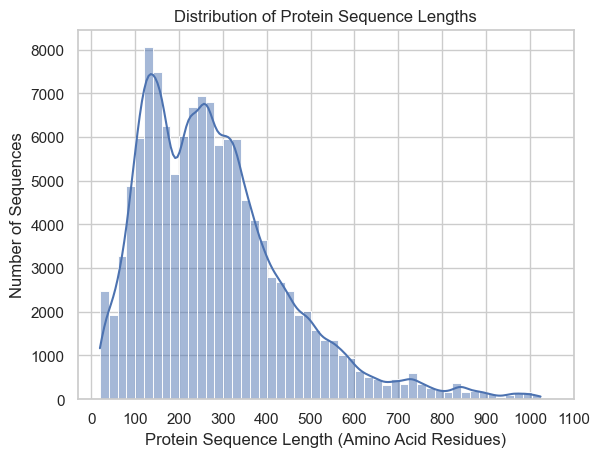

count   125891.00
mean       280.38
std        166.75
min         20.00
25%        154.00
50%        257.00
75%        363.00
max       1024.00
Name: sequence_length, dtype: float64

In [34]:
# Create function
def sequence_lengths(df):
    sns.histplot(df['sequence_length'], bins=50, kde=True)
    plt.title('Distribution of Protein Sequence Lengths')
    plt.xlabel('Protein Sequence Length (Amino Acid Residues)')
    plt.xticks(ticks=range(0, int(df['sequence_length'].max())+100, 100))
    plt.ylabel('Number of Sequences')
    plt.show()
    return

sequence_lengths(data)

# Describe distribution
data['sequence_length'].describe()

### 4.2. Classification

#### 4.2.1. Values

In [35]:
print(Counter(data['classification']))
print(len(Counter(data['classification'])))
print(data['classification'].value_counts().head(50))

Counter({'hydrolase': 20212, 'transferase': 15281, 'oxidoreductase': 12107, 'lyase': 4233, 'immune system': 3970, 'transcription': 3472, 'hydrolase/hydrolase inhibitor': 3413, 'transport protein': 3123, 'signaling protein': 2813, 'transferase/transferase inhibitor': 2533, 'isomerase': 2523, 'structural genomics, unknown function': 2450, 'viral protein': 2214, 'ligase': 2041, 'protein binding': 1845, 'membrane protein': 1649, 'dna binding protein': 1398, 'metal binding protein': 1329, 'sugar binding protein': 1305, 'cell adhesion': 1259, 'structural protein': 1227, 'electron transport': 1216, 'unknown function': 1209, 'chaperone': 1135, 'toxin': 1061, 'protein transport': 857, 'oxidoreductase/oxidoreductase inhibitor': 801, 'rna binding protein': 799, 'cell cycle': 716, 'gene regulation': 697, 'de novo protein': 543, 'virus': 514, 'lipid binding protein': 477, 'apoptosis': 470, 'metal transport': 468, 'transcription regulator': 431, 'oxygen transport': 429, 'hormone': 423, 'translation'

There are too many classes here to reliably model (3542). I will:
1. Check for redundancy
2. Select an amount of classes to examine further

#### 4.2.2. Synonyms

In [36]:
# Normalize classification text by making all uppercase and stripping whitespace and punctuation
data['classification'] = (
    data['classification']
    .str.upper()
    .str.strip()
    .str.replace(r'[^A-Z0-9 /]', '', regex=True)
)

# Extract top 20 classes
#top_20_classes = data['classification'].value_counts().head(20).index.tolist()
top_50_classes = data['classification'].value_counts().head(50).index.tolist()

# Check classes 21-30
#classes_21_30 = data['classification'][20:30]
#print(f"21st - 30th classes: {classes_21_30}")

# Check classes 31-50
#classes_31_50 = data['classification'][30:50]
#print(f"31st - 50th classes: {classes_31_50}")

# Use Fuzzywuzzy to check for synonyms
synonyms = {}

for c in top_50_classes:
    matches = process.extract(c, top_50_classes, limit=10)
    # Keep matches with similarity >= 90 (adjust threshold if needed)
    synonyms[c] = [m[0] for m in matches if m[1] >= 90 and m[0] != c]

synonyms

{'HYDROLASE': ['HYDROLASE/HYDROLASE INHIBITOR', 'HYDROLASE INHIBITOR'],
 'TRANSFERASE': ['TRANSFERASE/TRANSFERASE INHIBITOR'],
 'OXIDOREDUCTASE': ['OXIDOREDUCTASE/OXIDOREDUCTASE INHIBITOR'],
 'LYASE': ['LYASE/LYASE INHIBITOR'],
 'IMMUNE SYSTEM': [],
 'TRANSCRIPTION': ['TRANSCRIPTION REGULATOR'],
 'HYDROLASE/HYDROLASE INHIBITOR': ['HYDROLASE', 'HYDROLASE INHIBITOR'],
 'TRANSPORT PROTEIN': ['PROTEIN TRANSPORT'],
 'SIGNALING PROTEIN': [],
 'TRANSFERASE/TRANSFERASE INHIBITOR': ['TRANSFERASE'],
 'ISOMERASE': [],
 'STRUCTURAL GENOMICS UNKNOWN FUNCTION': ['UNKNOWN FUNCTION'],
 'VIRAL PROTEIN': [],
 'LIGASE': [],
 'PROTEIN BINDING': ['DNA BINDING PROTEIN',
  'METAL BINDING PROTEIN',
  'SUGAR BINDING PROTEIN',
  'RNA BINDING PROTEIN',
  'LIPID BINDING PROTEIN'],
 'MEMBRANE PROTEIN': [],
 'DNA BINDING PROTEIN': ['PROTEIN BINDING', 'RNA BINDING PROTEIN'],
 'METAL BINDING PROTEIN': ['PROTEIN BINDING'],
 'SUGAR BINDING PROTEIN': ['PROTEIN BINDING'],
 'CELL ADHESION': [],
 'STRUCTURAL PROTEIN': [],


In [37]:
# Step 1: define canonical classes for known clusters
canonical_classes = {
    'HYDROLASE': ['HYDROLASE INHIBITOR', 'HYDROLASE/HYDROLASE INHIBITOR', 'HYDROLASE OGLYCOSYL'],
    'TRANSFERASE': ['TRANSFERASE/TRANSFERASE INHIBITOR'],
    'OXIDOREDUCTASE': ['OXIDOREDUCTASE/OXIDOREDUCTASE INHIBITOR'],
    'LYASE': ['LYASE/LYASE INHIBITOR'],
    'IMMUNE SYSTEM': [],
    'TRANSCRIPTION': ['TRANSCRIPTION REGULATOR'],
    'TRANSPORT PROTEIN': ['PROTEIN TRANSPORT'],
    'SIGNALING PROTEIN': [],
    'ISOMERASE': [],
    'STRUCTURAL GENOMICS UNKNOWN FUNCTION': ['UNKNOWN FUNCTION'],
    'VIRAL PROTEIN': ['VIRAL PROTEIN/IMMUNE SYSTEM'],
    'LIGASE': ['LIGASE/LIGASE INHIBITOR'],
    'PROTEIN BINDING': ['DNA BINDING PROTEIN',
                        'RNA BINDING PROTEIN',
                        'METAL BINDING PROTEIN',
                        'SUGAR BINDING PROTEIN',
                        'LIPID BINDING PROTEIN'],
    'MEMBRANE PROTEIN': [],
    'DNA BINDING PROTEIN': ['PROTEIN BINDING', 'RNA BINDING PROTEIN'],
    'METAL BINDING PROTEIN': ['PROTEIN BINDING'],
    'SUGAR BINDING PROTEIN': ['PROTEIN BINDING'],
    'CELL ADHESION': [],
    'STRUCTURAL PROTEIN': [],
    'ELECTRON TRANSPORT': [],
    'UNKNOWN FUNCTION': ['STRUCTURAL GENOMICS UNKNOWN FUNCTION'],
    'CHAPERONE': [],
    'TOXIN': [],
    'PROTEIN TRANSPORT': ['TRANSPORT PROTEIN'],
    'RNA BINDING PROTEIN': ['PROTEIN BINDING', 'DNA BINDING PROTEIN'],
    'CELL CYCLE': [],
    'GENE REGULATION': [],
    'DE NOVO PROTEIN': [],
    'VIRUS': [],
    'LIPID BINDING PROTEIN': ['PROTEIN BINDING'],
    'APOPTOSIS': [],
    'METAL TRANSPORT': [],
    'TRANSCRIPTION REGULATOR': ['TRANSCRIPTION'],
    'OXYGEN TRANSPORT': [],
    'HORMONE': [],
    'TRANSLATION': [],
    'BIOSYNTHETIC PROTEIN': [],
    'FLUORESCENT PROTEIN': [],
    'PLANT PROTEIN': [],
    'ANTIMICROBIAL PROTEIN': [],
    'CYTOKINE': [],
    'OXYGEN STORAGE/TRANSPORT': [],
    'PHOTOSYNTHESIS': [],
    'MOTOR PROTEIN': [],
    'CONTRACTILE PROTEIN': []
}

def build_and_apply_canonical_map(df, 
                                  canonical_classes, 
                                  synonyms, 
                                  column='classification'):
    """
    Builds a canonical mapping dictionary and applies it to a dataframe column.
    Internally normalizes keys, strips parentheses, returns uppercase canonical values.
    """

    # -----------------------------
    # Step 1: Build canonical map
    # -----------------------------
    canonical_map = {}

    for can, variants in canonical_classes.items():
        can_clean = can.lower().strip()
        canonical_map[can_clean] = can_clean.upper()
        for v in variants:
            canonical_map[v.lower().strip()] = can_clean.upper()

    # -----------------------------
    # Step 2: Add synonyms
    # -----------------------------
    for key in list(synonyms.keys()):
        key_clean = key.lower().strip()
        if key_clean not in canonical_map:
            if '/' in key_clean:
                base = key_clean.split('/')[0].strip()
                canonical_map[key_clean] = base.upper()
                canonical_map.setdefault(base, base.upper())
            elif 'inhibitor' in key_clean:
                base = key_clean.replace(' inhibitor', '').strip()
                canonical_map[key_clean] = base.upper()
                canonical_map.setdefault(base, base.upper())
            else:
                canonical_map[key_clean] = key_clean.upper()

    # -----------------------------
    # Step 3: Apply mapping
    # -----------------------------
    def standardize(x):
        if pd.isna(x):
            return x
        x_clean = str(x).lower().strip()
        # remove parentheses
        x_clean = re.sub(r'\(.*?\)', '', x_clean).strip()
        # normalize spaces around slashes
        x_clean = x_clean.replace(' / ', '/')
        # map to canonical
        return canonical_map.get(x_clean, x_clean.upper())

    df = df.copy()
    df[column] = df[column].apply(standardize)

    return df, canonical_map

data, canonical_map = build_and_apply_canonical_map(data, canonical_classes, synonyms, column='classification')

print(Counter(data['classification']))
print(len(Counter(data['classification'])))
print(data['classification'].value_counts().head(50))

Counter({'HYDROLASE': 24110, 'TRANSFERASE': 17815, 'OXIDOREDUCTASE': 12908, 'LYASE': 4532, 'PROTEIN TRANSPORT': 3980, 'IMMUNE SYSTEM': 3970, 'TRANSCRIPTION REGULATOR': 3903, 'UNKNOWN FUNCTION': 3663, 'SIGNALING PROTEIN': 2813, 'ISOMERASE': 2523, 'VIRAL PROTEIN': 2434, 'LIPID BINDING PROTEIN': 2322, 'LIGASE': 2235, 'RNA BINDING PROTEIN': 2197, 'MEMBRANE PROTEIN': 1649, 'METAL BINDING PROTEIN': 1329, 'SUGAR BINDING PROTEIN': 1305, 'CELL ADHESION': 1259, 'STRUCTURAL PROTEIN': 1227, 'ELECTRON TRANSPORT': 1216, 'CHAPERONE': 1135, 'TOXIN': 1061, 'CELL CYCLE': 716, 'GENE REGULATION': 697, 'DE NOVO PROTEIN': 543, 'VIRUS': 514, 'APOPTOSIS': 470, 'METAL TRANSPORT': 468, 'OXYGEN TRANSPORT': 429, 'HORMONE': 423, 'TRANSLATION': 423, 'BIOSYNTHETIC PROTEIN': 398, 'FLUORESCENT PROTEIN': 356, 'PLANT PROTEIN': 346, 'ANTIMICROBIAL PROTEIN': 289, 'CYTOKINE': 284, 'OXYGEN STORAGE/TRANSPORT': 277, 'PHOTOSYNTHESIS': 264, 'MOTOR PROTEIN': 259, 'CONTRACTILE PROTEIN': 258, 'HORMONE/GROWTH FACTOR': 244, 'PEPTIDE

### Save AI CSV

In [38]:
# -----------------------------
# Config
# -----------------------------
protein_id_col = 'structure_id'   
chain_col = 'chain_id'
sequence_col = 'sequence'
target_col = 'classification'

# -----------------------------
# Step 0: Drop unnecessary columns
# -----------------------------
drop_cols_ai = ['combined_sequence', 'sequence_length']
data_ai = data_full.drop(columns=drop_cols_ai, errors='ignore')

# -----------------------------
# Step 1: Collapse → ONE sequence per chain
# -----------------------------
chain_sequences = (
    data_ai
    .groupby([protein_id_col, chain_col])[sequence_col]
    .first()  # assumes sequence already complete per chain
    .reset_index()
)

# -----------------------------
# Step 2: Create sequence index per protein
# -----------------------------
chain_sequences = chain_sequences.sort_values(by=[protein_id_col, chain_col])
chain_sequences['seq_idx'] = chain_sequences.groupby(protein_id_col).cumcount()

# Chain cap prevents extreme outliers with many chains from dominating the dataset and causing formatting/memory issues
max_chains = 20

# Count unique chains per protein
chain_counts = chain_sequences.groupby(protein_id_col)[chain_col].nunique()

# Keep only proteins within the cap
valid_proteins = chain_counts[chain_counts <= max_chains].index

# Filter both datasets
chain_sequences = chain_sequences[chain_sequences[protein_id_col].isin(valid_proteins)]
data_ai = data_ai[data_ai[protein_id_col].isin(valid_proteins)]

# -----------------------------
# Step 3: Clean sequences per chain (STRICT)
# -----------------------------
chain_sequences_clean = chain_sequences.dropna(subset=[sequence_col])

# Ensure sequences are valid strings only
chain_sequences_clean = chain_sequences_clean[
    chain_sequences_clean[sequence_col].apply(lambda x: isinstance(x, str))
]

# Remove duplicates (same protein + chain)
chain_sequences_clean = chain_sequences_clean.drop_duplicates(
    subset=[protein_id_col, chain_col]
)

# -----------------------------
# Step 4: Create a dictionary of chain sequences per protein
# -----------------------------
protein_sequences = chain_sequences_clean.groupby(protein_id_col).apply(
    lambda df: {cid: seq for cid, seq in zip(df[chain_col], df[sequence_col])}
).rename("chain_sequences")

# -----------------------------
# Step 5: Count chains per protein
# -----------------------------
protein_chain_count = chain_sequences_clean.groupby(protein_id_col)[sequence_col].count().rename("chain_count")

# -----------------------------
# Step 6: Merge metadata
# -----------------------------
non_seq_cols = [c for c in data_ai.columns if c not in [protein_id_col, chain_col, sequence_col]]
meta = data_ai.groupby(protein_id_col)[non_seq_cols].first()

# Combine
data_ai_combined = meta.join(protein_sequences).join(protein_chain_count).reset_index()

# -----------------------------
# Step 7: Fill numeric columns with medians
# -----------------------------
numeric_cols = data_ai_combined.select_dtypes(include=['number']).columns
for col in numeric_cols:
    data_ai_combined[col] = data_ai_combined[col].fillna(data_ai_combined[col].median())

# -----------------------------
# Step 8: Standardize classes
# -----------------------------
data_ai_combined, canonical_map = build_and_apply_canonical_map(
    data_ai_combined, canonical_classes, synonyms, column=target_col
)

# -----------------------------
# Step 9: Remove structure_id, resolution, and chain_count columns (potential data leakage)
# -----------------------------
data_ai_combined = data_ai_combined.drop(columns=[protein_id_col, 'chain_count'], errors='ignore')

# -----------------------------
# Step 10: Save & check
# -----------------------------
data_ai_combined.to_csv("data_ai.csv", index=False)

print(data_ai_combined.shape)
print(data_ai_combined.head())

# -----------------------------
# Step 11: Generate segmented class .csvs
# -----------------------------
# Count number of records per class
class_counts = data_ai_combined[target_col].value_counts()

# 1️⃣ Top 3 classes (> 10000 records)
top3_classes = class_counts[class_counts > 10000].index
data_top3 = data_ai_combined[data_ai_combined[target_col].isin(top3_classes)]
data_top3.to_csv("data_ai_high_classes.csv", index=False)

# 2️⃣ Classes between 1000 and 10000 records, inclusive
mid_classes = class_counts[(class_counts >= 1000) & (class_counts <= 10000)].index
data_mid = data_ai_combined[data_ai_combined[target_col].isin(mid_classes)]
data_mid.to_csv("data_ai_mid_classes.csv", index=False)

# 3️⃣ Remaining classes down to 200 records
low_classes = class_counts[(class_counts < 1000) & (class_counts >= 200)].index
data_low = data_ai_combined[data_ai_combined[target_col].isin(low_classes)]
data_low.to_csv("data_ai_low_classes.csv", index=False)

# Print counts for verification
print("Top 3 classes saved:", len(top3_classes))
print("Mid classes saved:", len(mid_classes))
print("Low classes saved:", len(low_classes))

(124954, 7)
     classification  resolution  structure_molecular_weight  density_matthews  \
0  OXYGEN TRANSPORT        2.07                    18112.80              3.09   
1         HYDROLASE        1.74                    18926.61              2.75   
2  OXYGEN TRANSPORT        1.84                    18010.64              3.09   
3         HYDROLASE        1.90                    19092.72              2.70   
4  OXYGEN TRANSPORT        2.07                    18093.78              3.09   

   density_percent_sol  ph_value  \
0                60.20      9.00   
1                55.28      7.00   
2                60.20      9.00   
3                54.46      7.00   
4                60.30      9.00   

                                     chain_sequences  
0  {'A': 'MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPE...  
1  {'A': 'MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSL...  
2  {'A': 'MVLSEGEWQLVLHVWAKVEADVAGHGQDILIRLFKSHPE...  
3  {'A': 'MNIFEMLRIDEGLRLKIYKDTEGYYTIGIGHLLTKSPSL...  
4  {'A': 

Based on the top 50 classes, the below rules will be followed:
1. Up to the top 50 classes, with any synonyms included.
3. An "OTHER" class to capture the remainder of any biologically relevant classes, if needed.
4. Classes must be represented by at least 200 sequences.

#### 4.2.2. Frequency

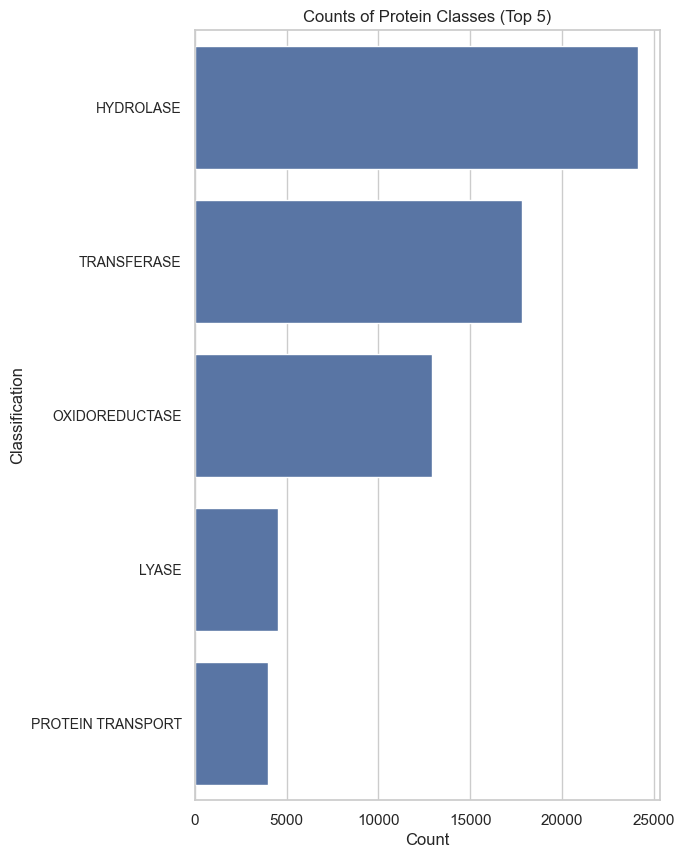

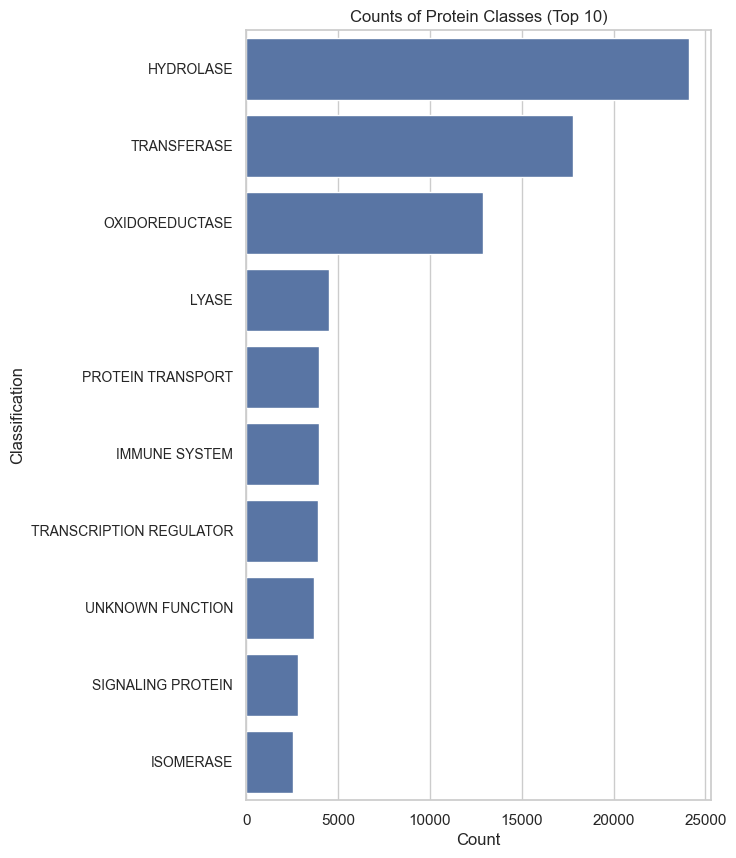

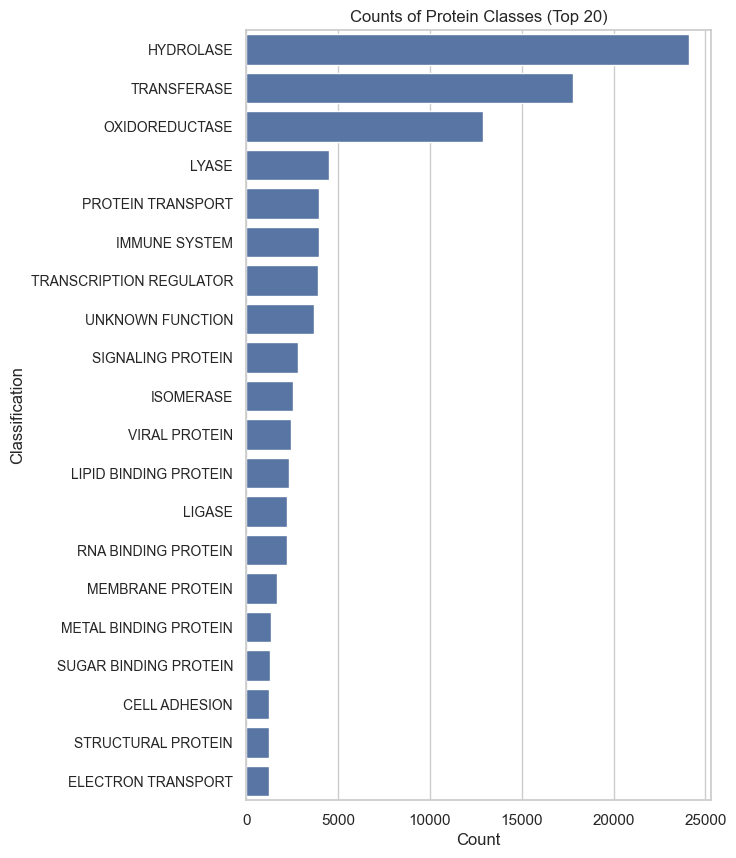

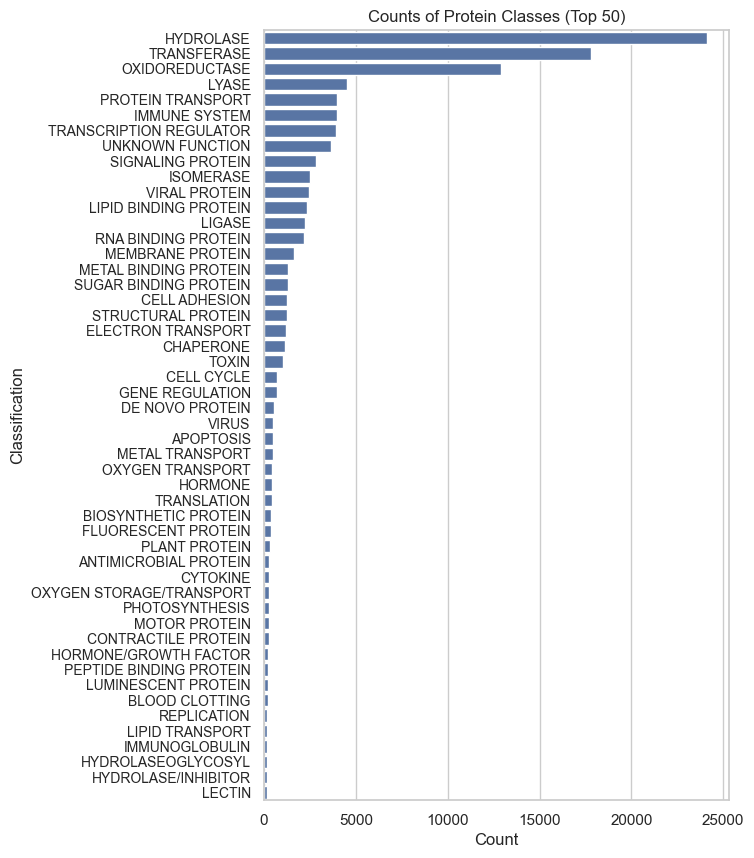

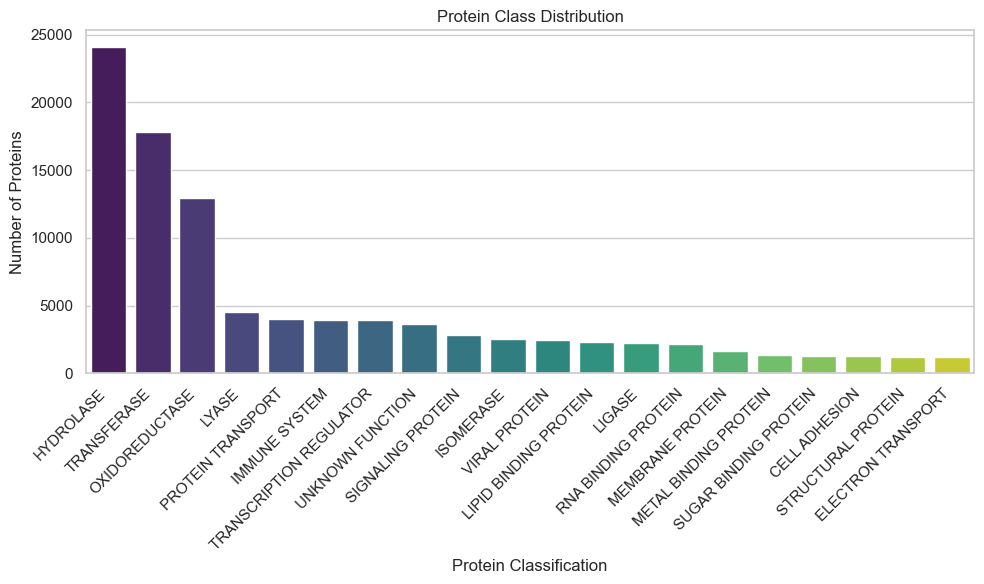

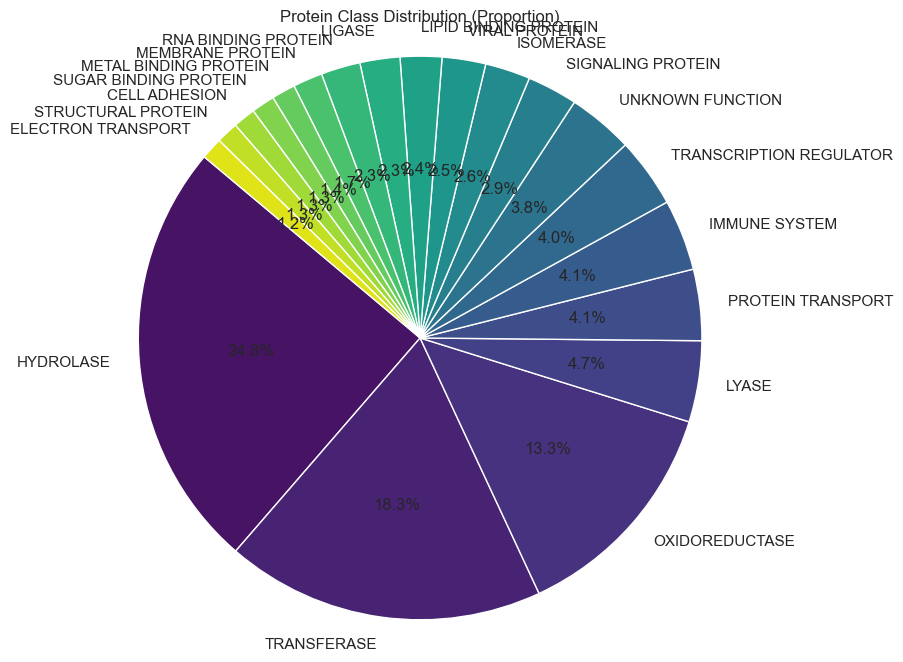

In [39]:
# Plotting function
def classification_plot(n):
    counts = data['classification'].value_counts().sort_values(ascending=False).head(n)

    plt.figure(figsize=(6, 10))
    sns.barplot(x=counts.values, y=counts.index)
    plt.xlabel("Count")
    plt.ylabel("Classification")
    plt.title(f"Counts of Protein Classes (Top {n})")
    plt.yticks(fontsize=10)
    plt.show()
    return

# Add 5, 10, and 15
classification_plot(5)
classification_plot(10)
classification_plot(20)
classification_plot(50)

# Final plots, top 50
# Count proteins per class
class_counts = data['classification'].value_counts().head(20)

# Bar chart of class distribution
plt.figure(figsize=(10, 6))
sns.barplot(
    x=class_counts.index, 
    y=class_counts.values, 
    palette="viridis"
)
plt.xticks(rotation=45, ha='right')
plt.title('Protein Class Distribution')
plt.xlabel('Protein Classification')
plt.ylabel('Number of Proteins')
plt.tight_layout()
plt.show()

# Pie chart of class distribution
plt.figure(figsize=(8, 8))
plt.pie(
    class_counts.values, 
    labels=class_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=sns.color_palette("viridis", len(class_counts))
)
plt.title('Protein Class Distribution (Proportion)')
plt.axis('equal')
plt.show()

We can see a large imbalance in the top 50 classes, which will need to be accounted for later.

### 4.3. Sequences vs. Classification

The models being explored here do best with fewer than 50 classes and/or more than 200 sets of data (sequences in this case). Below, we can rank the classes by their nmber of representative sequences and decide on breakpoints.

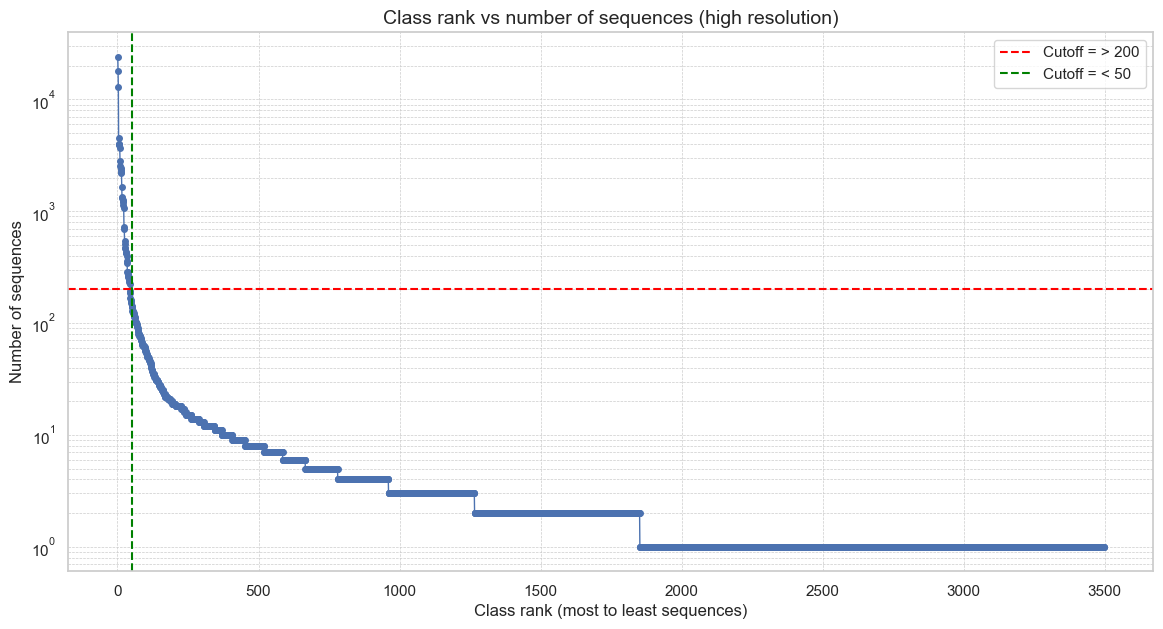

In [40]:
# Count sequences per class
class_counts = data['classification'].value_counts().sort_values(ascending=False)

# Create rank index
ranks = range(1, len(class_counts)+1)

# Plot
plt.figure(figsize=(14,7))
plt.plot(ranks, class_counts.values, marker='o', markersize=4, linewidth=1)
plt.xlabel('Class rank (most to least sequences)', fontsize=12)
plt.ylabel('Number of sequences', fontsize=12)
plt.title('Class rank vs number of sequences (high resolution)', fontsize=14)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Cutoff lines
# Sequences (> 200)
y_cutoff = 200
plt.axhline(y=y_cutoff, color='red', linestyle='--', label=f'Cutoff = > {y_cutoff}')
# Number of classes (< 50)
x_cutoff = 50
plt.axvline(x=x_cutoff, color='green', linestyle='--', label=f'Cutoff = < {x_cutoff}')
plt.legend()

# Optional: log scale to emphasize lower counts
plt.yscale('log')
plt.show()

In [41]:
# Filter classes (start with top 20)
top_classes = class_counts.head(20).index.tolist()
top_classes

['HYDROLASE',
 'TRANSFERASE',
 'OXIDOREDUCTASE',
 'LYASE',
 'PROTEIN TRANSPORT',
 'IMMUNE SYSTEM',
 'TRANSCRIPTION REGULATOR',
 'UNKNOWN FUNCTION',
 'SIGNALING PROTEIN',
 'ISOMERASE',
 'VIRAL PROTEIN',
 'LIPID BINDING PROTEIN',
 'LIGASE',
 'RNA BINDING PROTEIN',
 'MEMBRANE PROTEIN',
 'METAL BINDING PROTEIN',
 'SUGAR BINDING PROTEIN',
 'CELL ADHESION',
 'STRUCTURAL PROTEIN',
 'ELECTRON TRANSPORT']

### 4.4. Amino Acids

#### 4.4.1. Composition

##### 4.4.1.1. Heatmap

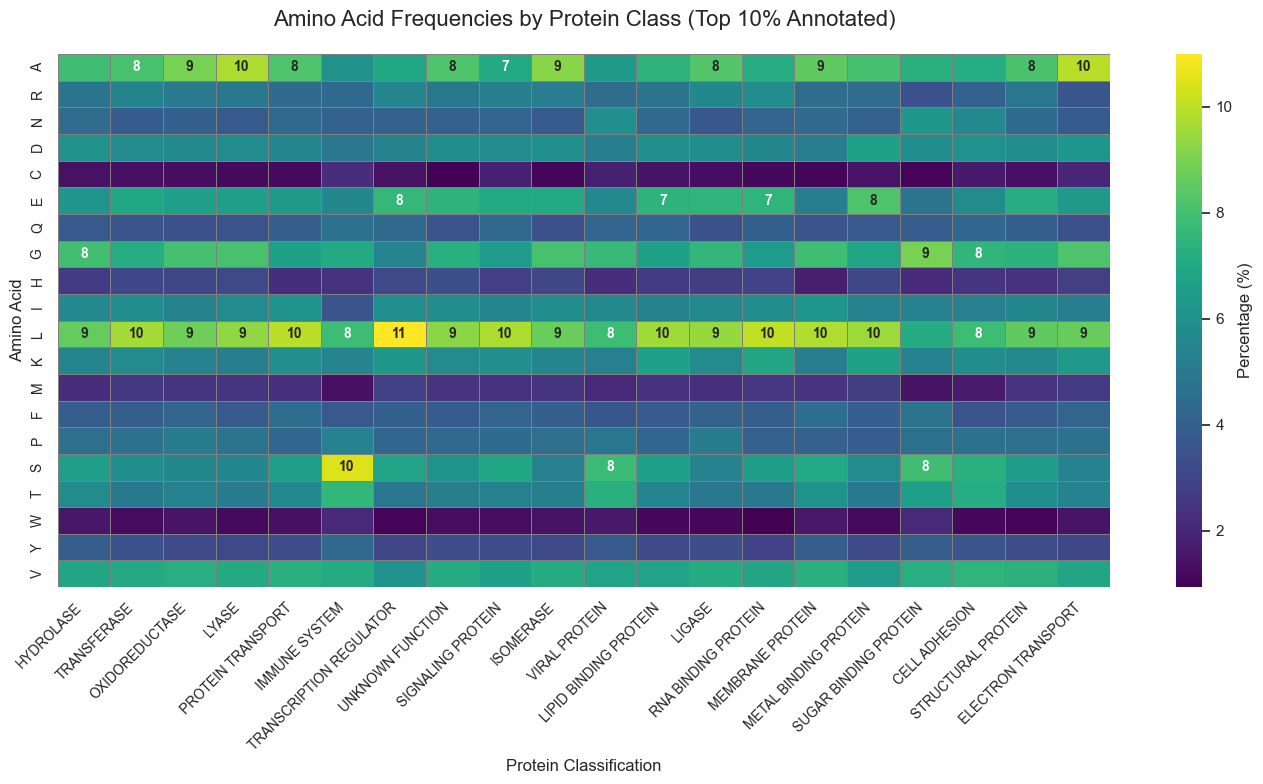

In [42]:
# AA composition heatmap by class

# Amino acid list
aa_list = list("ARNDCEQGHILKMFPSTWYV")

# Select top 20 classes by sequence count
top_classes = data['classification'].value_counts().nlargest(20).index
data_top = data[data['classification'].isin(top_classes)]

# Count amino acids per class
class_counts = {}
for cls in top_classes:
    sequences = data_top.loc[data_top['classification'] == cls, 'combined_sequence']
    all_seq = ''.join(sequences)
    aa_counts = pd.Series(list(all_seq)).value_counts()
    aa_counts = aa_counts.reindex(aa_list, fill_value=0)
    class_counts[cls] = aa_counts

# Create DataFrame with columns in top_classes order
aa_df = pd.DataFrame(class_counts)[top_classes]  # force top 20 only

# Convert counts to percentages per class
aa_percent = aa_df.div(aa_df.sum(axis=0), axis=1) * 100

# Annotate only top 10% values
thresholds = aa_percent.quantile(0.9)
annot_df = aa_percent.copy()
annot_df = annot_df.where(aa_percent >= thresholds)
annot_df = annot_df.applymap(lambda x: f"{x:.0f}" if not pd.isna(x) else "")

# Plot settings
plt.figure(figsize=(14, 8))
sns.set(style="whitegrid")  # cleaner background
sns.heatmap(
    aa_percent,
    cmap="viridis",
    annot=annot_df,
    fmt="",
    linewidths=0.5,
    linecolor='gray',
    cbar_kws={"label": "Percentage (%)"},
    annot_kws={"ha": "center", "va": "center", "size": 10, "weight": "bold"}  # centered annotations
)

# Titles and labels
plt.title("Amino Acid Frequencies by Protein Class (Top 10% Annotated)", fontsize=16, pad=20)
plt.xlabel("Protein Classification", fontsize=12)
plt.ylabel("Amino Acid", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

##### 4.4.1.2. Bar and Pie Charts

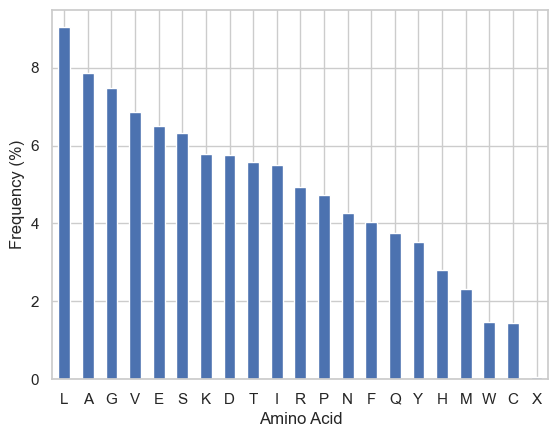

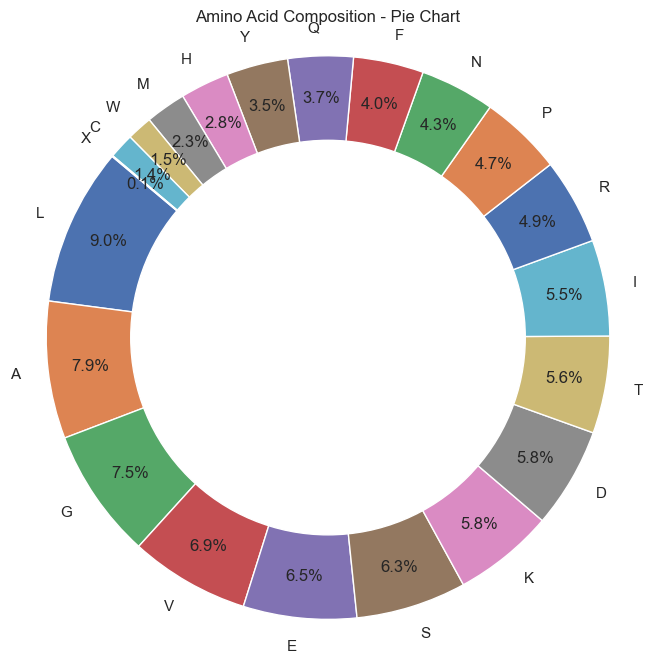

In [43]:
# Create function for bar and pie charts of amino acid composition
def aa_composition(df):
    aa_counts = Counter("".join(df['sequence']))
    aa_freq = {aa: count / sum(aa_counts.values()) * 100 for aa, count in aa_counts.items()}
    aa_df = pd.DataFrame(list(aa_freq.items()), columns=['Amino Acid', 'Frequency']).sort_values('Frequency', ascending=False)
    # Bar chart
    aa_df.plot(kind='bar', x='Amino Acid', y='Frequency', legend=False)
    plt.ylabel('Frequency (%)')
    plt.xticks(rotation=0)
    plt.show()
    
    # Pie chart
    plt.figure(figsize=(8,8))
    plt.pie(aa_df['Frequency'], labels=aa_df['Amino Acid'], autopct='%1.1f%%', startangle=140, pctdistance=0.85)
    plt.title('Amino Acid Composition - Pie Chart')
    
    # Draw a circle in the center to make it look nicer
    centre_circle = plt.Circle((0,0),0.70,fc='white')
    fig = plt.gcf()
    fig.gca().add_artist(centre_circle)
    plt.axis('equal')  # Equal aspect ratio ensures pie is circular
    plt.show()
    
aa_composition(data)

#### 4.4.2. Biochemical Groups

##### 4.4.2.1. Heatmap

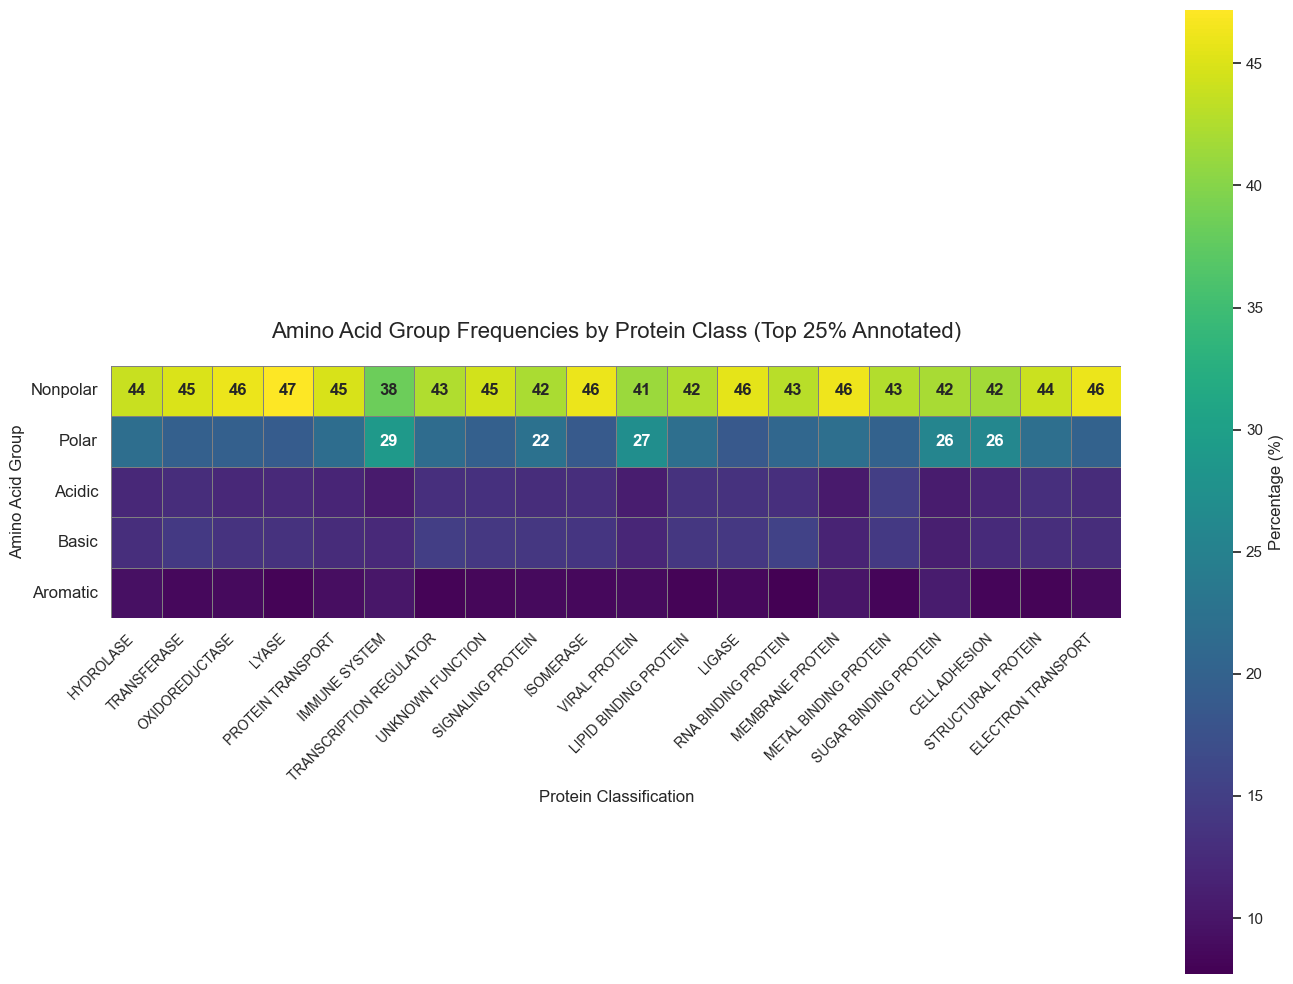

In [44]:
# Define biochemical groups
aa_groups = {
    "Nonpolar": ["A", "V", "L", "I", "M", "P", "G"],
    "Polar": ["S", "T", "C", "N", "Q"],
    "Acidic": ["D", "E"],
    "Basic": ["K", "R", "H"],
    "Aromatic": ["F", "W", "Y"]
}

# Count amino acids per class
aa_list = list("ARNDCEQGHILKMFPSTWYV")

# Select top 20 classes
top_classes = data['classification'].value_counts().nlargest(20).index
data_top = data[data['classification'].isin(top_classes)]

# Count amino acids per class
class_counts = {}
for cls in top_classes:
    sequences = data_top.loc[data_top['classification'] == cls, 'combined_sequence']
    all_seq = ''.join(sequences)
    aa_counts = pd.Series(list(all_seq)).value_counts()
    aa_counts = aa_counts.reindex(aa_list, fill_value=0)
    class_counts[cls] = aa_counts

aa_df = pd.DataFrame(class_counts)  # rows: amino acids, columns: classes

# Aggregate by group
group_df = pd.DataFrame(index=aa_groups.keys(), columns=aa_df.columns, dtype=float)
for group_name, aas in aa_groups.items():
    group_df.loc[group_name] = aa_df.loc[aa_df.index.isin(aas)].sum()

# Convert counts to percentages per class
group_percent = group_df.div(group_df.sum(axis=0), axis=1) * 100

# --- Top 25% annotation ---
# Flatten the DataFrame using stack() and get 90th percentile
threshold = group_percent.stack().quantile(0.75)

# Annotate only values >= threshold
annot_df = group_percent.copy().astype(str)
annot_df = annot_df.where(group_percent >= threshold, "")
annot_df = annot_df.applymap(lambda x: f"{float(x):.0f}" if x != "" else "")

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.set(style="whitegrid")

ax = sns.heatmap(
    group_percent,
    cmap="viridis",
    annot=annot_df,
    fmt="",
    linewidths=0.5,
    linecolor='gray',
    square=True,
    cbar_kws={"label": "Percentage (%)"},
    annot_kws={"ha": "center", "va": "center", "size": 12, "weight": "bold"}
)

plt.title("Amino Acid Group Frequencies by Protein Class (Top 25% Annotated)", fontsize=16, pad=20)
plt.xlabel("Protein Classification", fontsize=12)
plt.ylabel("Amino Acid Group", fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=12)

plt.tight_layout()
plt.show()

##### 4.4.2.2. Bar Chart

                               hydrophobic  polar  acidic  basic  aromatic
classification                                                            
3EPIMERASE                            0.42   0.19    0.12   0.12      0.05
53 EXO/ENDO NUCLEASE                  0.37   0.14    0.16   0.18      0.10
ABSCISIC ACID BINDING PROTEIN         0.40   0.20    0.13   0.11      0.06
ACARBOSE                              0.41   0.19    0.12   0.15      0.10
ACETYLATION                           0.35   0.24    0.17   0.11      0.02
...                                    ...    ...     ...    ...       ...
ZINCFINGER PROTEIN                    0.37   0.29    0.18   0.07      0.07
ZN BINDING PROTEIN                    0.39   0.23    0.10   0.12      0.12
ZNBINDING PROTEIN                     0.36   0.19    0.18   0.16      0.08
ZNENDOPEPTIDASE                       0.30   0.23    0.14   0.14      0.11
ZORBAMYCIN BINDING PROTEIN            0.44   0.20    0.16   0.09      0.09

[3498 rows x 5 columns]


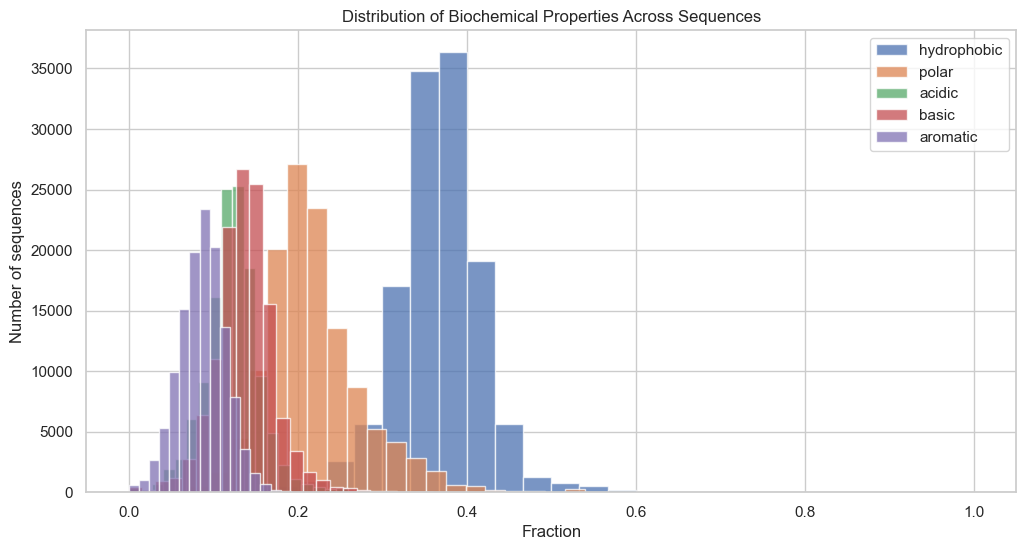

In [45]:
# Create function for bar chart of biochemical properties
def biochemical_properties(df):
    hydrophobic_set = set('AILMFWV')
    polar_uncharged_set = set('CSTNQ')
    acidic_set = set('DE')
    basic_set = set('KRH')
    aromatic_set = set('FYW')

    # Compute fractions as local Series, not assigned to df
    hydrophobic = df['sequence'].apply(lambda s: sum(aa in hydrophobic_set for aa in s)/len(s))
    polar = df['sequence'].apply(lambda s: sum(aa in polar_uncharged_set for aa in s)/len(s))
    acidic = df['sequence'].apply(lambda s: sum(aa in acidic_set for aa in s)/len(s))
    basic = df['sequence'].apply(lambda s: sum(aa in basic_set for aa in s)/len(s))
    aromatic = df['sequence'].apply(lambda s: sum(aa in aromatic_set for aa in s)/len(s))

    properties = {
        'hydrophobic': hydrophobic,
        'polar': polar,
        'acidic': acidic,
        'basic': basic,
        'aromatic': aromatic
    }

    # Optional: average per class
    class_props = pd.DataFrame(properties).join(df['classification']).groupby('classification').mean()
    print(class_props)

    # Plot histogram for each property
    plt.figure(figsize=(12,6))
    for prop_name, prop_values in properties.items():
        plt.hist(prop_values, bins=30, alpha=0.75, label=prop_name)

    plt.xlabel('Fraction')
    plt.ylabel('Number of sequences')
    plt.title('Distribution of Biochemical Properties Across Sequences')
    plt.legend()
    plt.show()

biochemical_properties(data)

### 4.4.3. Secondary Stucture

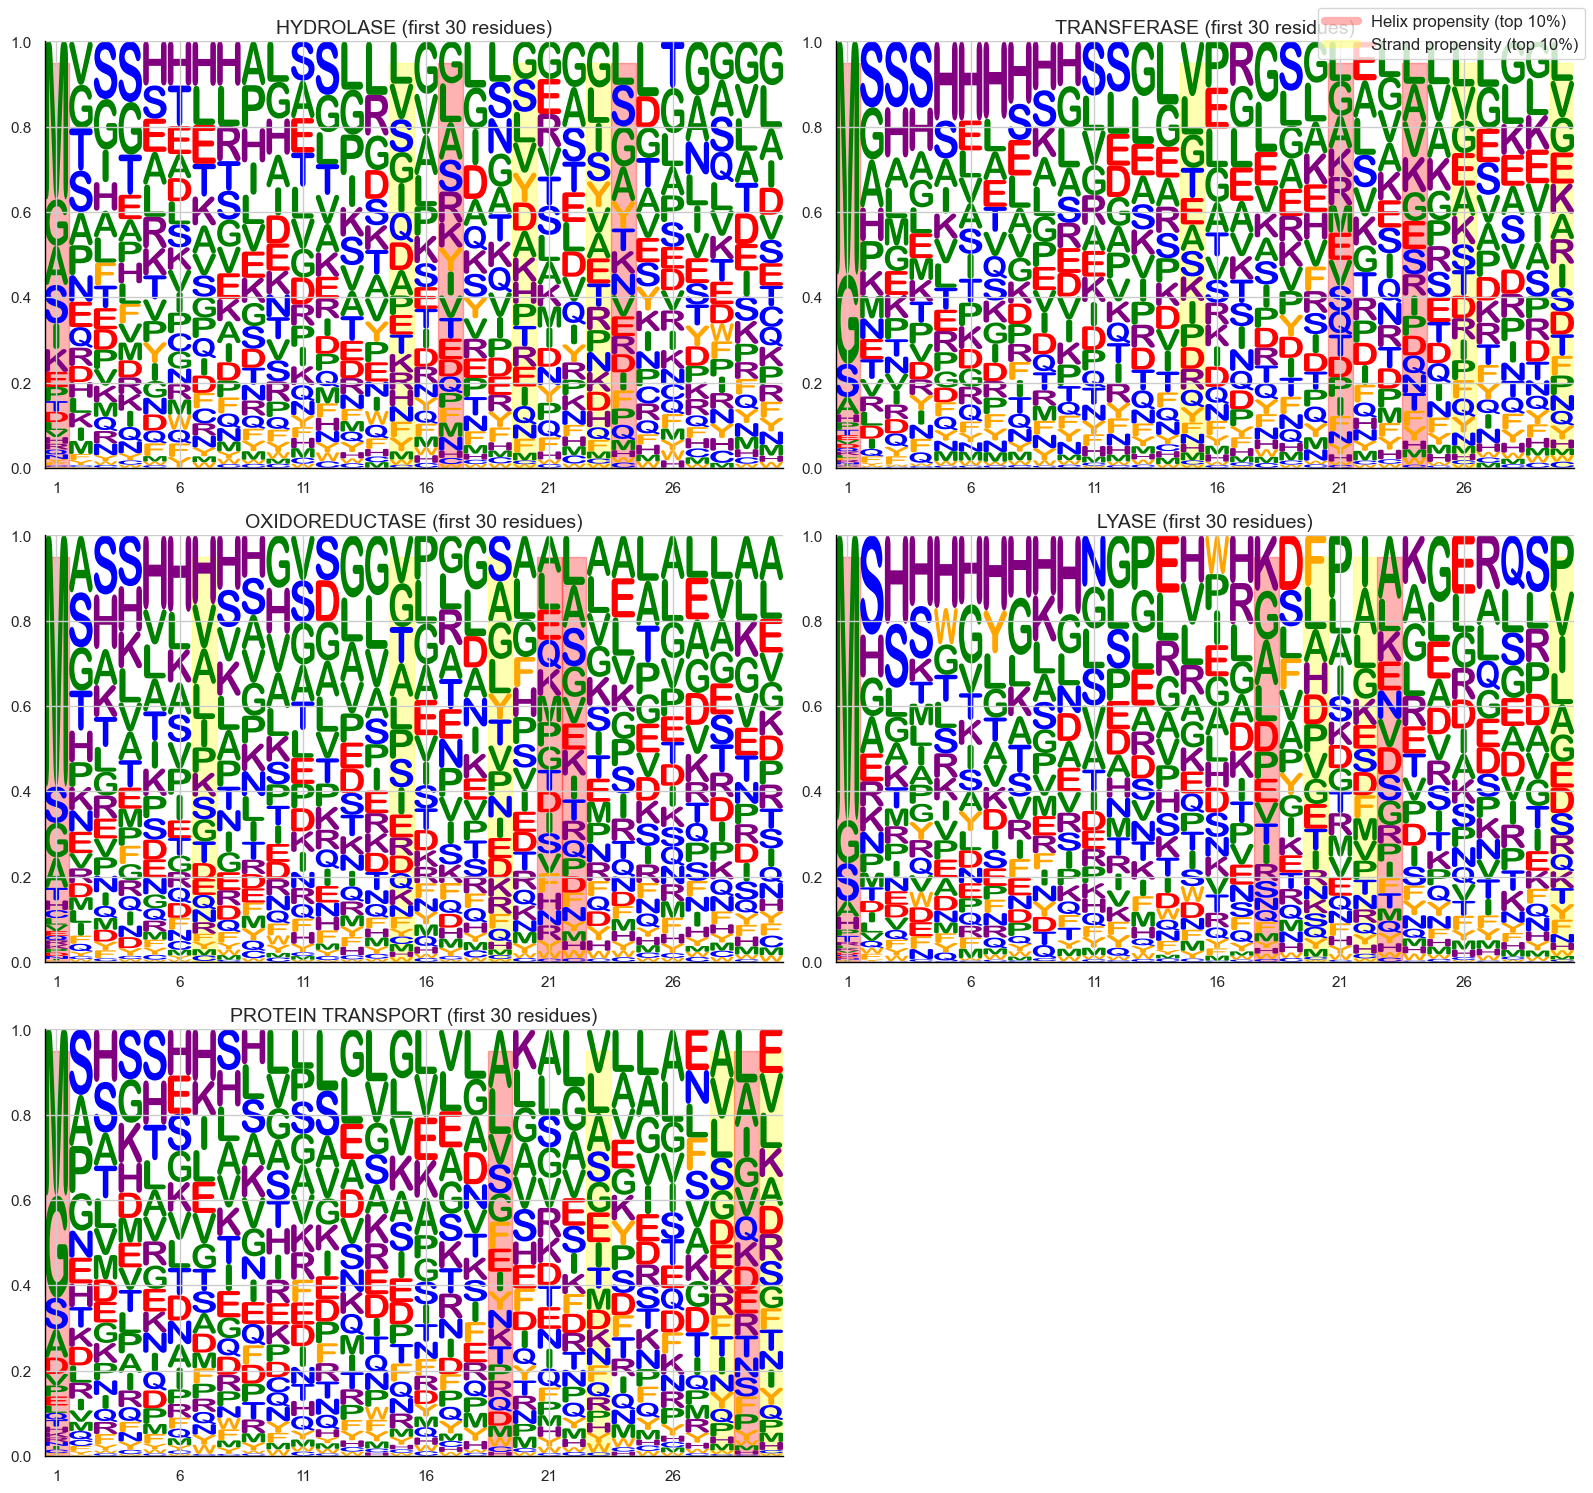

In [46]:
# -------------------------------
# Parameters
# -------------------------------
max_length = 30
alphabet = "ACDEFGHIKLMNPQRSTVWY"
color_scheme = {
    'A':'green','V':'green','L':'green','I':'green','M':'green','P':'green','G':'green',  # Nonpolar
    'S':'blue','T':'blue','C':'blue','N':'blue','Q':'blue',  # Polar
    'D':'red','E':'red',  # Acidic
    'K':'purple','R':'purple','H':'purple',  # Basic
    'F':'orange','W':'orange','Y':'orange'   # Aromatic
}

helix_aa = set("ALMFKQ")
strand_aa = set("VIFY")

# -------------------------------
# Functions
# -------------------------------
def generate_motif_overlay(sequences):
    """Estimate secondary structure positions based on residue propensity"""
    overlay = []
    for pos in range(max_length):
        column = sequences.str.slice(pos,pos+1)
        h_frac = sum([1 for aa in column if aa in helix_aa]) / len(column)
        e_frac = sum([1 for aa in column if aa in strand_aa]) / len(column)
        overlay.append((h_frac, e_frac))
    return overlay

def sequences_to_pwm(sequences):
    pwm = pd.DataFrame(0, index=list(alphabet), columns=range(len(sequences.iloc[0])))
    for seq in sequences:
        for pos, aa in enumerate(seq):
            if aa in alphabet:
                pwm.at[aa, pos] += 1
    pwm = pwm / pwm.sum(axis=0)
    return pwm

# -------------------------------
# Prepare figure
# -------------------------------
top_classes = data['classification'].value_counts().index[:5]
n_classes = len(top_classes)
ncols = 2
nrows = (n_classes + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 5*nrows))
axes = axes.flatten()

for i, cls in enumerate(top_classes):
    cls_sequences = data.loc[data['classification']==cls,'combined_sequence'].str[:max_length]
    pwm = sequences_to_pwm(cls_sequences)
    overlay = generate_motif_overlay(cls_sequences)

    # Compute percentile thresholds for this class
    h_thresh = np.percentile([h for h,e in overlay], 90)
    e_thresh = np.percentile([e for h,e in overlay], 90)
    
    # Plot logo
    logo = logomaker.Logo(
        pwm.T,
        ax=axes[i],
        shade_below=.5,
        fade_below=.5,
        font_name='Arial Rounded MT Bold',
        color_scheme=color_scheme
    )
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left','bottom'], visible=True)
    
    # X-axis ticks and labels
    axes[i].set_xticks(range(0, max_length, 5))
    axes[i].set_xticklabels(range(1, max_length+1, 5))
    axes[i].set_title(f"{cls} (first {max_length} residues)", fontsize=14)
    
    # Overlay rectangles for top 10% helix/strand positions
    for pos, (h_frac, e_frac) in enumerate(overlay):
        if h_frac >= h_thresh:
            axes[i].add_patch(
                mpatches.Rectangle((pos-0.5, -0.05), 1, 1.0, color='red', alpha=0.3, zorder=-1)
            )
        if e_frac >= e_thresh:
            axes[i].add_patch(
                mpatches.Rectangle((pos-0.5, -0.05), 1, 1.0, color='yellow', alpha=0.3, zorder=-1)
            )

# Remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Figure-level legend
legend_elements = [
    Line2D([0], [0], color='red', lw=6, alpha=0.3, label='Helix propensity (top 10%)'),
    Line2D([0], [0], color='yellow', lw=6, alpha=0.3, label='Strand propensity (top 10%)')
]
fig.legend(handles=legend_elements, loc='upper right', fontsize=12)

plt.tight_layout()
plt.show()

### 4.4.4. PCA Plot

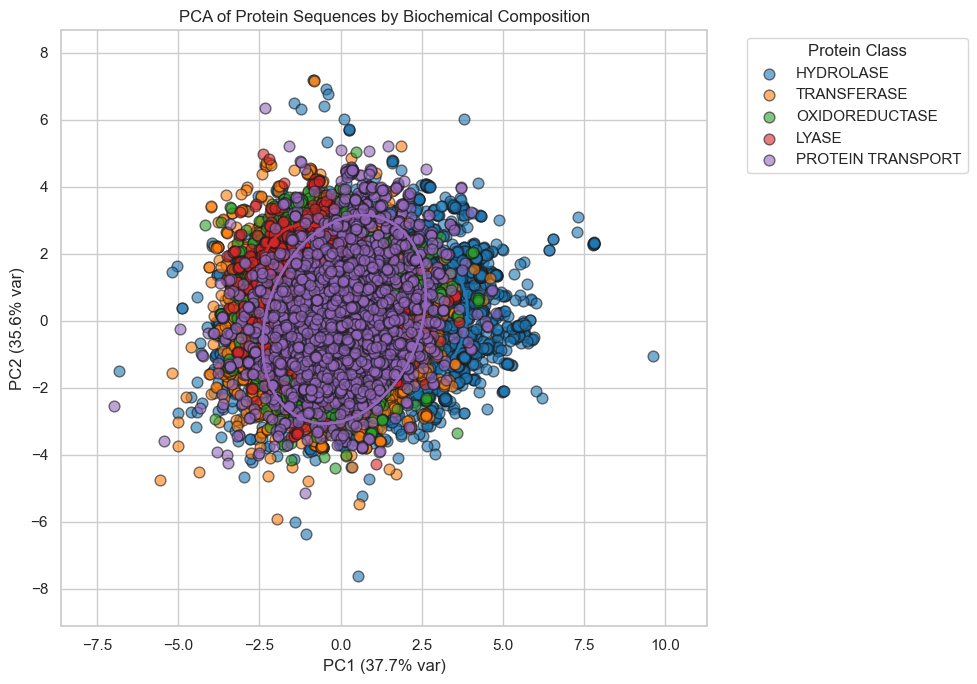

In [47]:
# -------------------------------
# Parameters
# -------------------------------
aa_groups = {
    'Nonpolar': list("AGILMPV"),
    'Polar': list("STCNQ"),
    'Acidic': list("DE"),
    'Basic': list("KRH"),
    'Aromatic': list("FWY")
}

top_classes = data['classification'].value_counts().index[:5]
max_jitter = 0.02  # optional jitter to separate overlapping points

# -------------------------------
# Compute AA group fractions
# -------------------------------
def compute_group_fractions(seq):
    seq_len = len(seq)
    return pd.Series({group: sum(seq.count(aa) for aa in aas)/seq_len for group, aas in aa_groups.items()})

aa_features = data['combined_sequence'].apply(compute_group_fractions)
aa_features['classification'] = data['classification']
aa_features = aa_features[aa_features['classification'].isin(top_classes)]

X_aa = aa_features[list(aa_groups.keys())]
y_aa = aa_features['classification']

# -------------------------------
# Standardize and PCA
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_aa)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# -------------------------------
# Helper function to plot ellipses
# -------------------------------
def plot_ellipse(ax, x, y, n_std=2.0, **kwargs):
    cov = np.cov(x, y)
    mean_x, mean_y = np.mean(x), np.mean(y)
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * n_std * np.sqrt(vals)
    ellipse = Ellipse(xy=(mean_x, mean_y), width=width, height=height, angle=theta, **kwargs)
    ax.add_patch(ellipse)

# -------------------------------
# Plot PCA
# -------------------------------
plt.figure(figsize=(10, 7))
colors = plt.cm.tab10.colors
color_dict = {cls: colors[i % 10] for i, cls in enumerate(top_classes)}

ax = plt.gca()
for cls in top_classes:
    idx = y_aa == cls
    # optional jitter
    X_plot = X_pca[idx] + np.random.normal(0, max_jitter, X_pca[idx].shape)
    ax.scatter(X_plot[:,0], X_plot[:,1], color=color_dict[cls], label=cls,
               alpha=0.6, edgecolors='k', s=60)
    # add confidence ellipse
    plot_ellipse(ax, X_plot[:,0], X_plot[:,1], n_std=2.0, edgecolor=color_dict[cls],
                 facecolor='none', lw=2)

# -------------------------------
# Expand axes slightly
# -------------------------------
x_min, x_max = X_pca[:,0].min(), X_pca[:,0].max()
y_min, y_max = X_pca[:,1].min(), X_pca[:,1].max()
padding_x = 0.1 * (x_max - x_min)
padding_y = 0.1 * (y_max - y_min)
ax.set_xlim(x_min - padding_x, x_max + padding_x)
ax.set_ylim(y_min - padding_y, y_max + padding_y)

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
plt.title('PCA of Protein Sequences by Biochemical Composition')
plt.legend(title='Protein Class', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### 4.5 *k*-mer Frequency

#### 4.5.1. Heatmap

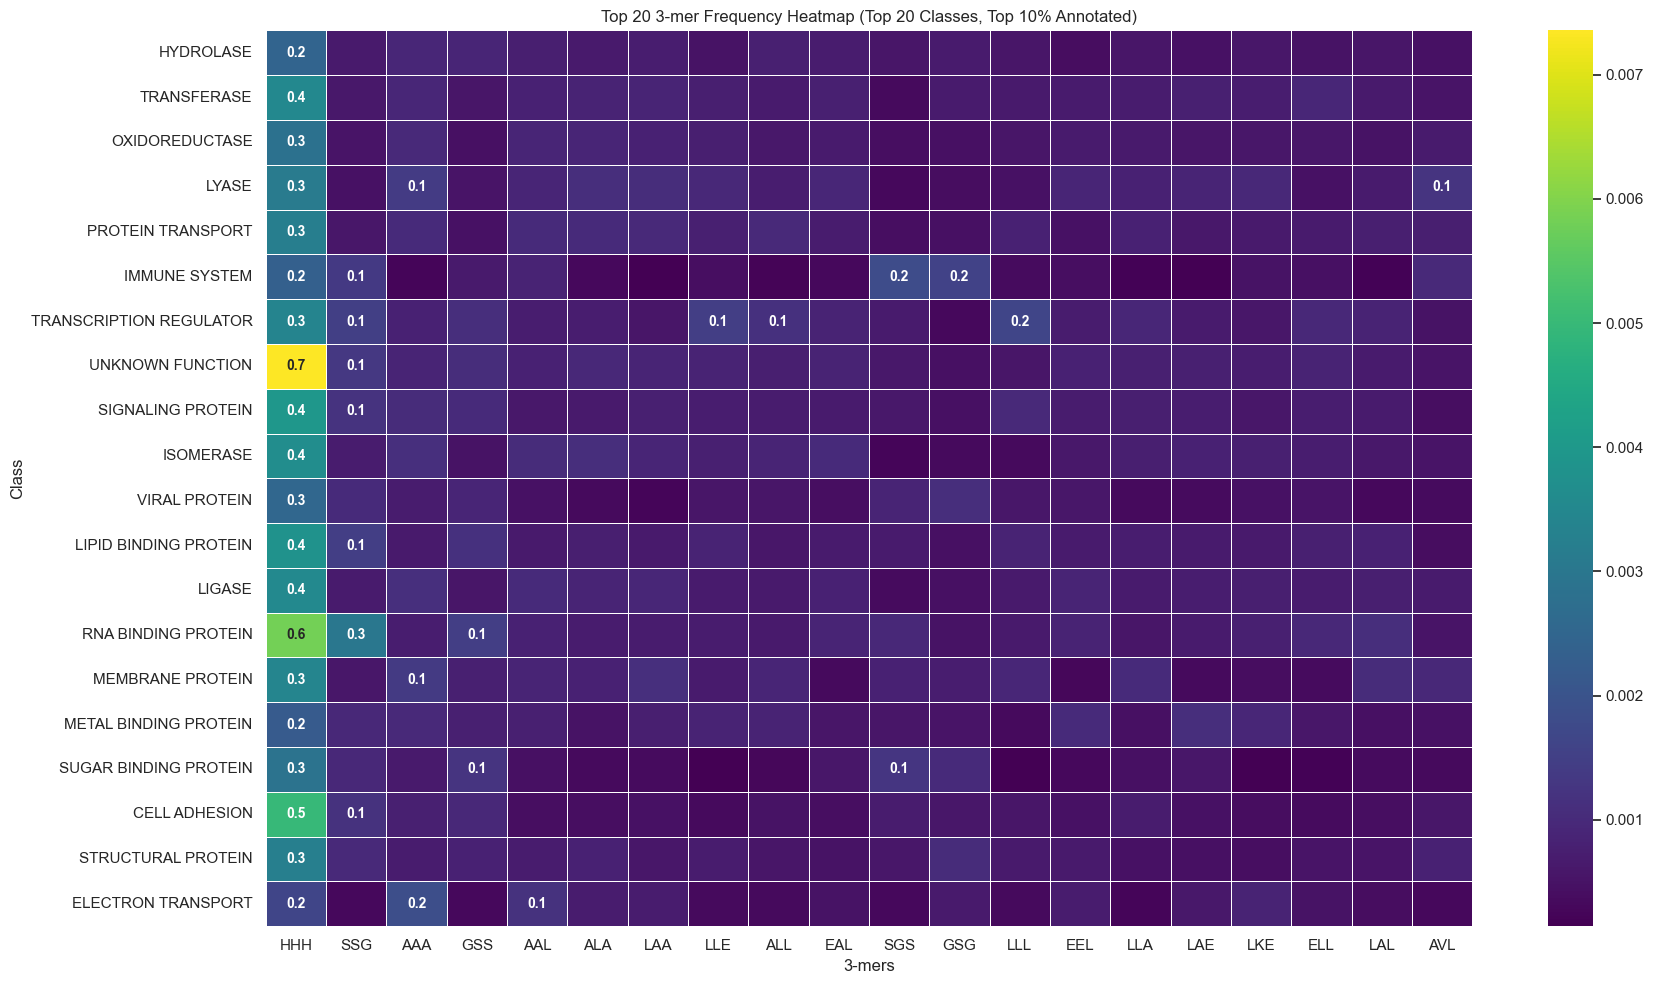

In [48]:
# -----------------------------
# Function to get k-mers
# -----------------------------
def get_kmers(seq, k=3):
    return [seq[i:i+k] for i in range(len(seq)-k+1) if 'X' not in seq[i:i+k]]

k = 3

# -----------------------------
# Select top 20 classes FIRST
# -----------------------------
top_classes = data['classification'].value_counts().nlargest(20).index
data_top = data[data['classification'].isin(top_classes)]

# -----------------------------
# Count k-mers per class
# -----------------------------
class_kmers = {cls: Counter() for cls in top_classes}

for cls, group in data_top.groupby('classification'):
    for seq in group['sequence']:
        class_kmers[cls].update(get_kmers(seq, k=k))

class_kmer_df = pd.DataFrame.from_dict(class_kmers, orient='index').fillna(0)

# -----------------------------
# Normalize per class (SAFE)
# -----------------------------
row_sums = class_kmer_df.sum(axis=1)

# Avoid division by zero
class_kmer_freq = class_kmer_df.div(row_sums.replace(0, np.nan), axis=0).fillna(0)

# -----------------------------
# Select top 20 k-mers globally
# -----------------------------
top_cols = class_kmer_freq.sum(axis=0).sort_values(ascending=False).index[:20]

# -----------------------------
# Log transform
# -----------------------------
heatmap_data = np.log1p(class_kmer_freq[top_cols])

# -----------------------------
# Top 10% annotation on % scale
# -----------------------------
annot_source = class_kmer_freq[top_cols] * 100

threshold = annot_source.stack().quantile(0.9)

annot_df = annot_source.where(annot_source >= threshold)
annot_df = annot_df.applymap(lambda x: f"{x:.1f}" if not pd.isna(x) else "")

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(18,10))
sns.heatmap(
    heatmap_data,
    cmap='viridis',
    annot=annot_df,
    fmt="",
    linewidths=0.5,
    annot_kws={"size": 10, "weight": "bold"}
)

plt.title(f'Top 20 {k}-mer Frequency Heatmap (Top 20 Classes, Top 10% Annotated)')
plt.ylabel('Class')
plt.xlabel(f'{k}-mers')

plt.tight_layout()
plt.show()

#### 4.5.2. Bar Chart and WordCloud

In [49]:
"""
# Functions
def get_kmers(sequence, k=3):
    return [sequence[i:i+k] for i in range(len(sequence)-k+1) if 'X' not in sequence[i:i+k]]

def count_kmers_in_dataset(sequences, k=3, top_n=20):
    counter = Counter()
    for seq in sequences:
        if len(seq) >= k:
            counter.update(get_kmers(seq, k))
    return counter.most_common(top_n)

def plot_top_kmers(sequences, k=3, top_n=20, title=None):
    top_kmers = count_kmers_in_dataset(sequences, k, top_n)
    if not top_kmers:
        print(f"No {k}-mers found.")
        return

    kmers, counts = zip(*top_kmers)
    plt.figure(figsize=(12,5))
    plt.bar(kmers, counts, color='steelblue')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel("Count")
    plt.xlabel(f"{k}-mers")

    # Annotate counts in truncated format (e.g., 56000 -> 56k)
    def truncate_number(n):
        if n >= 1_000_000:
            return f"{n//1_000_000}M"
        elif n >= 1_000:
            return f"{n//1_000}k"
        else:
            return str(n)

    for i, count in enumerate(counts):
        plt.text(i, count + max(counts)*0.01, truncate_number(count), ha='center', va='bottom', fontsize=9)

    if title is None:
        title = f"Top {top_n} {k}-mers"
    plt.title(title, fontsize=14)
    plt.tight_layout()
    plt.show()

def wordcloud_kmers(sequences, k=3, max_words=50, title=None):
    counter = Counter()
    for seq in sequences:
        if len(seq) >= k:
            counter.update(get_kmers(seq, k))
    if not counter:
        print(f"No {k}-mers found.")
        return

    text = " ".join(chain.from_iterable([kmer]*count for kmer, count in counter.items()))
    wc = WordCloud(width=800, height=400, background_color='white', max_words=max_words)
    wc.generate(text)

    plt.figure(figsize=(14,6))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    if title is None:
        title = f"{k}-mer Word Cloud"
    plt.title(title, fontsize=16)
    plt.show()

# Pre-filter sequences once for max k
max_k = 4
valid_sequences = [seq for seq in data['combined_sequence'] if len(seq) >= max_k]

k_mers=[2]

for k in [k_mers]:
    plot_top_kmers(valid_sequences, k=k, top_n=20, title=f"Top 20 {k}-mers")
    wordcloud_kmers(valid_sequences, k=k, max_words=50, title=f"{k}-mer Word Cloud")
    """

'\n# Functions\ndef get_kmers(sequence, k=3):\n    return [sequence[i:i+k] for i in range(len(sequence)-k+1) if \'X\' not in sequence[i:i+k]]\n\ndef count_kmers_in_dataset(sequences, k=3, top_n=20):\n    counter = Counter()\n    for seq in sequences:\n        if len(seq) >= k:\n            counter.update(get_kmers(seq, k))\n    return counter.most_common(top_n)\n\ndef plot_top_kmers(sequences, k=3, top_n=20, title=None):\n    top_kmers = count_kmers_in_dataset(sequences, k, top_n)\n    if not top_kmers:\n        print(f"No {k}-mers found.")\n        return\n\n    kmers, counts = zip(*top_kmers)\n    plt.figure(figsize=(12,5))\n    plt.bar(kmers, counts, color=\'steelblue\')\n    plt.xticks(rotation=45, ha=\'right\')\n    plt.ylabel("Count")\n    plt.xlabel(f"{k}-mers")\n\n    # Annotate counts in truncated format (e.g., 56000 -> 56k)\n    def truncate_number(n):\n        if n >= 1_000_000:\n            return f"{n//1_000_000}M"\n        elif n >= 1_000:\n            return f"{n//1_000}

<div style="width: 100%; background-color: #1565C0; text-align: left; font-size: 30px; padding: 10px; border-radius: 5px;">
  <strong>5. Model Training and Evaluation</strong>
</div>

### 5.1. Select Final Data for Modeling

In [50]:
# Define features
included_cols = [
    #'combined_sequence',         # combined sequence of all chains
    'resolution',                # structure resolution
    'structure_molecular_weight',# molecular weight of the structure
    'density_matthews',          # Matthews density
    'density_percent_sol',       # percent solvent content
    'ph_value',                  # pH of crystallization
    'sequence_length',           # length of the protein sequence
    'frac_aromatic',             # fraction of aromatic residues
    'frac_nonpolar',             # fraction of nonpolar residues
    'frac_polar',                # fraction of polar residues
    'frac_acidic',               # fraction of acidic residues
    'frac_basic',                # fraction of basic residues
    # Individual amino acid fractions
    'frac_A', 'frac_C', 'frac_D', 'frac_E', 'frac_F',
    'frac_G', 'frac_H', 'frac_I', 'frac_K', 'frac_L',
    'frac_M', 'frac_N', 'frac_P', 'frac_Q', 'frac_R',
    'frac_S', 'frac_T', 'frac_V', 'frac_W', 'frac_Y'
]

# top_classes = [...]  # list of your N chosen classes
top_classes = data['classification'].value_counts().nlargest(20).index.tolist()
data_final = data[data['classification'].isin(top_classes)].reset_index(drop=True)

# Adjust dataframes to match X and y only
data_final = data_final[included_cols + ['classification']]

# Check
print(data_final.shape)
print(data_final.head(10))
print(data_final.columns.tolist())

X = data_final[included_cols]
y = data_final['classification']

# Save as csv for final modeling data
data_final.to_csv("data_final.csv", index=False)

print("X:")
print(X.shape)
print(X.head())

print("y:")
print(y.shape)
print(y.head())

(97390, 32)
   resolution  structure_molecular_weight  density_matthews  \
0        2.20                    47830.70              2.61   
1        2.15                    65203.21              2.71   
2        2.50                    73530.97              2.30   
3        2.06                    28700.28              2.48   
4        1.90                    30391.41              2.40   
5        2.30                    48366.94              2.53   
6        2.20                    74225.41              2.30   
7        2.10                    48013.14              2.50   
8        1.90                    48752.68              2.63   
9        2.80                    47146.02              2.64   

   density_percent_sol  ph_value  sequence_length  frac_aromatic  \
0                52.86      5.80              209           0.10   
1                54.69      6.00              286           0.10   
2                47.00      7.50              330           0.07   
3                50.36

### 5.3. Split Dataset (Training, Validation, Test)

In [51]:
def train_test_split_custom (X, y, size, state):
    """
    Generates training, validation, and test datasets given parameters:
    X: feature(s)
    y: target
    size: size (%) of training set
    state: random state value
    """
    X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=1-size/100,
    stratify=y,
    random_state=state
    )

    X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

    return X_train, X_val, X_test, y_train, y_val, y_test

size = 70   # Size (%) of training set
state = 42  # Random state for reproducibility

# Run function
X_train, X_val, X_test, y_train, y_val, y_test = train_test_split_custom(X, y, size, state)

# Check shapes
print("X:")
print(X_train.shape, X_val.shape, X_test.shape)

print()
print("y:")
print(y_train.shape, y_val.shape, y_test.shape)

X:
(68172, 31) (14609, 31) (14609, 31)

y:
(68172,) (14609,) (14609,)


### 5.3. Preprocessing `X` and `y`

#### 5.3.1. `X`

`X` has some numeric features that are not yet scaled.

In [52]:
# Columns to scale - the rest are already on 0-1 scale (fractions)
scale_cols = [
    'resolution',
    'structure_molecular_weight',
    'density_matthews',
    'density_percent_sol',
    'ph_value',
    'sequence_length'
]

# Initialize scaler
scaler = StandardScaler()

# Fit and transform only the selected columns
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])
X_val[scale_cols]   = scaler.transform(X_val[scale_cols])

##### 5.3.1.1 Save scaler .pkl

In [53]:
# Save scaler
with open("saved_models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

#### 5.3.2. `y`

`y` needs to be encoded.

In [29]:
# Use LabelEncoder to encode y
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

print(y_train_enc.shape, y_val_enc.shape, y_test_enc.shape)

(67733,) (14514,) (14515,)


### 5.4. Address Feature Imbalance

SMOTE will be used to address feature imbalance.

In [43]:
def apply_smote(X_train, y_train):
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    return X_train_res, y_train_res




# Run separated SMOTE as well (top 3 + bottom 17)
# Create separate X and y for top 3 and bottom 17 classes
# Top 3 classes
X_train_top3 = X_train[y_train.isin(y_train.value_counts().nlargest(3).index)]
y_train_top3_enc = y_train_enc[y_train.isin(y_train.value_counts().nlargest(3).index)]

# Classes 4-20
X_train_bottom17 = X_train[~y_train.isin(y_train.value_counts().nlargest(3).index)]
y_train_bottom17_enc = y_train_enc[~y_train.isin(y_train.value_counts().nlargest(3).index)]

# Separate SMOTE on top 3 and bottom 17 separately to avoid over-sampling the already large classes
# Top 3 classes
print("----- Top 3 Classes:")
print("Top 3 X:", X_train_top3.shape)
print("Top 3 y:", y_train_top3_enc.shape)
print("Top 3 y:", Counter(y_train_top3_enc))

X_train_top3_res, y_train_top3_enc_res = apply_smote(X_train_top3, y_train_top3_enc)

print("Top 3 X (resampled):", X_train_top3_res.shape)
print("Top 3 y (resampled):", y_train_top3_enc_res.shape)
print("Top 3 y (resampled):", Counter(y_train_top3_enc_res))

# Classes 4-20
print("\n----- Bottom 17 Classes:")
print("Bottom 17 X:", X_train_bottom17.shape)
print("Bottom 17 y:", y_train_bottom17_enc.shape)
print("Bottom 17 y:", Counter(y_train_bottom17_enc))

X_train_bottom17_res, y_train_bottom17_enc_res = apply_smote(X_train_bottom17, y_train_bottom17_enc)

print("Bottom 17 X (resampled):", X_train_bottom17_res.shape)
print("Bottom 17 y (resampled):", y_train_bottom17_enc_res.shape)
print("Bottom 17 y (resampled):", Counter(y_train_bottom17_enc_res))

# Combine separated SMOTE back together
X_train_separate_SMOTE = pd.concat([X_train_top3_res, X_train_bottom17_res], axis=0).reset_index(drop=True)
y_train_separate_SMOTE = pd.concat([pd.Series(y_train_top3_enc_res), pd.Series(y_train_bottom17_enc_res)]).reset_index(drop=True)

print("\n----- Result of Separate SMOTE:")
print("Result of Separate SMOTE X:", X_train_separate_SMOTE.shape)
print("Result of Separate SMOTE y:", y_train_separate_SMOTE.shape)
print("Result of Separate SMOTE y:", Counter(y_train_separate_SMOTE))


# Combined SMOTE
print("\n-----Combined SMOTE (All 20 classes together):")
print(X_train.shape)
print(y_train.shape)
print(Counter(y_train_enc))

X_train_res, y_train_enc_res = apply_smote(X_train, y_train_enc)

print(X_train_res.shape)
print(y_train_enc_res.shape)
print(Counter(y_train_enc_res))

----- Top 3 Classes:
Top 3 X: (38234, 31)
Top 3 y: (38234,)
Top 3 y: Counter({np.int64(2): 16728, np.int64(17): 12470, np.int64(10): 9036})
Top 3 X (resampled): (50184, 31)
Top 3 y (resampled): (50184,)
Top 3 y (resampled): Counter({np.int64(10): 16728, np.int64(17): 16728, np.int64(2): 16728})

----- Bottom 17 Classes:
Bottom 17 X: (29499, 31)
Bottom 17 y: (29499,)
Bottom 17 y: Counter({np.int64(7): 3172, np.int64(11): 2786, np.int64(3): 2779, np.int64(16): 2732, np.int64(18): 2564, np.int64(13): 1969, np.int64(4): 1766, np.int64(6): 1625, np.int64(19): 1550, np.int64(12): 1538, np.int64(5): 1429, np.int64(8): 1154, np.int64(9): 930, np.int64(15): 914, np.int64(0): 881, np.int64(14): 859, np.int64(1): 851})
Bottom 17 X (resampled): (53924, 31)
Bottom 17 y (resampled): (53924,)
Bottom 17 y (resampled): Counter({np.int64(16): 3172, np.int64(7): 3172, np.int64(3): 3172, np.int64(5): 3172, np.int64(1): 3172, np.int64(11): 3172, np.int64(12): 3172, np.int64(18): 3172, np.int64(15): 3172, n

### 5.5. Baseline Models with LazyClassifier

LazyClassifier will be used to see which models perform the best at baseline with no tuning.

In [44]:
# Run LazyClassifier
clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=None)
models, predictions = clf.fit(X_train_res, X_test, y_train_enc_res, y_test_enc)

print(models)

  0%|          | 0/32 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025756 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7905
[LightGBM] [Info] Number of data points in the train set: 334560, number of used features: 31
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGBM] [Info] Start training from score -2.995732
[LightGB

#### 5.6. RandomForestClassifier

Random Forest will be explored further and optimized with Optuna.

In [45]:
# RandomForestClassifier
def objective_randomforest(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 800)
    max_depth = trial.suggest_int('max_depth', 5, 100)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    
    model = RandomForestClassifier(n_estimators=n_estimators,
                                    max_depth=max_depth,
                                    min_samples_split=min_samples_split,
                                    min_samples_leaf=min_samples_leaf,
                                    max_features=max_features,
                                    class_weight=class_weight,
                                    bootstrap=bootstrap,
                                    random_state=42,
                                    n_jobs=-1
    )
    cv = StratifiedKFold(n_splits=5, 
                         shuffle=True, 
                         random_state=42)
    score = cross_val_score(model, 
                            X_train_res, 
                            y_train_enc_res, 
                            cv=cv, 
                            scoring='f1_weighted').mean()
    return score

In [ ]:
# Run Optimizations
print("\nOptimizing RandomForestClassifier...")
study = optuna.create_study(direction="maximize", 
                            sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective_randomforest, 
            n_trials=25, 
            #n_jobs=-1, 
            show_progress_bar=True)

# Compare Results
print("\nBest RandomForest params:", study.best_params)
print("Best RandomForest accuracy:", study.best_value)

[I 2026-03-21 16:42:49,025] A new study created in memory with name: no-name-082ca0e4-330a-49a9-bb76-cd315efaf9c0



Optimizing RandomForestClassifier...


  0%|          | 0/100 [00:00<?, ?it/s]

[W 2026-03-21 16:46:38,430] Trial 8 failed with parameters: {'n_estimators': 651, 'max_depth': 99, 'min_samples_split': 6, 'min_samples_leaf': 2, 'max_features': None, 'class_weight': None, 'bootstrap': True} because of the following error: MemoryError((267648, 1), dtype('float64')).
Traceback (most recent call last):
  File "c:\Users\palon\Envs\mlgpu\Lib\site-packages\optuna\study\_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\palon\AppData\Local\Temp\ipykernel_31852\1032521158.py", line 24, in objective_randomforest
    score = cross_val_score(model,
           ^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\palon\Envs\mlgpu\Lib\site-packages\sklearn\utils\_param_validation.py", line 218, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\palon\Envs\mlgpu\Lib\site-packages\sklearn\model_selection\_validation.py", line 677, in cross_val_score
    cv_results = cross_validate

In [46]:
# RandomForestClassifier
def objective_randomforest(trial):
    n_estimators = trial.suggest_int('n_estimators', 100, 800)
    max_depth = trial.suggest_int('max_depth', 5, 100)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 5)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    bootstrap = trial.suggest_categorical('bootstrap', [True, False])
    
    model = RandomForestClassifier(n_estimators=n_estimators,
                                    max_depth=max_depth,
                                    min_samples_split=min_samples_split,
                                    min_samples_leaf=min_samples_leaf,
                                    max_features=max_features,
                                    class_weight=class_weight,
                                    bootstrap=bootstrap,
                                    random_state=42,
                                    n_jobs=-1
    )
    cv = StratifiedKFold(n_splits=5, 
                         shuffle=True, 
                         random_state=42)
    score = cross_val_score(model, 
                            X_train_separate_SMOTE, 
                            y_train_separate_SMOTE, 
                            cv=cv, 
                            scoring='f1_weighted').mean()
    return score

In [47]:
# Rerun optimization with separate SMOTE (3 + 17 classes separately)
# Run Optimizations
print("\nOptimizing RandomForestClassifier...")
study_separate_smote = optuna.create_study(direction="maximize", 
                            sampler=optuna.samplers.TPESampler(seed=42))
study_separate_smote.optimize(objective_randomforest, 
            n_trials=25, 
            #n_jobs=-1, 
            show_progress_bar=True)

# Compare Results
print("\nBest RandomForest params:", study_separate_smote.best_params)
print("Best RandomForest accuracy:", study_separate_smote.best_value)

[I 2026-03-23 11:33:04,831] A new study created in memory with name: no-name-f57089bd-90d0-474e-80b7-e803c45476f4



Optimizing RandomForestClassifier...


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-03-23 11:35:19,044] Trial 0 finished with value: 0.7890427433394762 and parameters: {'n_estimators': 362, 'max_depth': 96, 'min_samples_split': 8, 'min_samples_leaf': 3, 'max_features': 'sqrt', 'class_weight': None, 'bootstrap': True}. Best is trial 0 with value: 0.7890427433394762.
[I 2026-03-23 12:03:21,166] Trial 1 finished with value: 0.8129797370035053 and parameters: {'n_estimators': 779, 'max_depth': 84, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': None, 'bootstrap': True}. Best is trial 1 with value: 0.8129797370035053.
[I 2026-03-23 12:15:03,420] Trial 2 finished with value: 0.7908477501010271 and parameters: {'n_estimators': 304, 'max_depth': 40, 'min_samples_split': 6, 'min_samples_leaf': 4, 'max_features': None, 'class_weight': 'balanced', 'bootstrap': True}. Best is trial 1 with value: 0.8129797370035053.
[I 2026-03-23 12:21:17,314] Trial 3 finished with value: 0.8303407458234779 and parameters: {'n_estimators': 765, 'max_dep

KeyboardInterrupt: 

In [ ]:
# Optuna plots
def generate_optuna_plots(study):
# List of plots to generate
    plots = {
    "Optimization History": plot_optimization_history,
    "Parameter Importances": plot_param_importances,
    "Parallel Coordinate": plot_parallel_coordinate,
    "Contour": plot_contour
    }

    # Create folder for saved plots
    os.makedirs("images", exist_ok=True)

    # Loop through and display + save each plot
    for name, plot_func in plots.items():
        fig = plot_func(study)
        
        # Show in notebook
        fig.show()
        
        # Save interactive HTML
        html_file = f"images/{name.replace(' ', '_').lower()}.html"
        fig.write_html(html_file)
        
        # Save static PNG (requires kaleido)
        try:
            png_file = f"{name.replace(' ', '_').lower()}.png"
            fig.write_image(png_file)
        except Exception as e:
            print(f"Could not save {png_file}: {e}")

    print("All Optuna plots displayed and saved!")
    
# Generate plots
#generate_optuna_plots(study)
generate_optuna_plots(study_separate_smote)

All Optuna plots displayed and saved!


### 5.7. Model Evaluation

In [ ]:
# Dictionary of best models from each study
best_models = {
    "RandomForest": RandomForestClassifier(**study.best_params, random_state=42, n_jobs=-1)
}

# Train and evaluate each optimized model
for name, model in best_models.items():
    print(f"\n===== {name} (Best Optuna Params) =====")
    model.fit(X_train_res, y_train_enc_res)
    preds = model.predict(X_test)
    
    acc = accuracy_score(y_test_enc, preds)
    print(f"Accuracy: {acc:.3f}\n")
    print("Classification Report:")
    print(classification_report(y_test_enc, preds))

# Save each optimized model with Pickle
# Create folder for saved models
os.makedirs("saved_models", exist_ok=True)

# Save each model
for name, model in best_models.items():
    filename = f"saved_models/{name}_optuna.pkl"
    with open(filename, "wb") as f:
        pickle.dump(model, f)
    print(f"Saved: {filename}")


===== RandomForest (Best Optuna Params) =====
Accuracy: 0.791

Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.67      0.56       189
           1       0.73      0.88      0.80       182
           2       0.95      0.85      0.90      3585
           3       0.83      0.87      0.85       596
           4       0.81      0.75      0.78       379
           5       0.74      0.74      0.74       306
           6       0.45      0.52      0.48       349
           7       0.83      0.81      0.82       680
           8       0.71      0.68      0.70       247
           9       0.60      0.56      0.58       199
          10       0.87      0.90      0.89      1936
          11       0.77      0.68      0.72       597
          12       0.55      0.62      0.59       329
          13       0.61      0.60      0.61       422
          14       0.63      0.58      0.60       184
          15       0.69      0.83      0.75     

In [40]:
# Read best .pkl file for hyperparameters

# Load the model
model_path = "saved_models/RandomForest_optuna.pkl"
with open (model_path, "rb") as f:
    rf = pickle.load(f)
print(rf.get_params())

MemoryError: could not allocate 16445920 bytes

### 5.8. Results

| Method                  | Test Accuracy (%) |
|:------------------------:|:-----------------:|
| Random Forest     | 79.1           |


<div style="width: 100%; background-color: #1565C0; text-align: left; font-size: 30px; padding: 10px; border-radius: 5px;">
  <strong>6. Conclusion</strong>
</div>

This project highlights how different ML methods interact with protein sequence data. Random Forest appears to struggle with complex proteomics data (accuracy = 79.1%). We expect agentic AI to offer vast improvement.

The future is within gentic AI capabilities for protein analysis and drug design. This so-called “Intelligent Drug Design” appears to be the new way forward to solve the intricate biochemical interactions required by the compounds to have the desired therapeutic effects.

<div style="width: 100%; background-color: #1565C0; text-align: left; font-size: 30px; padding: 10px; border-radius: 5px;">
  <strong>7. Accompanying Article</strong>
</div>

Please see the accompanying article of a previous version of this project for further information: 


---

**Machine Learning Classification of Structural Protein Sequences for Drug Discovery**

*Paul London, M.S. & Ernest Bonat, Ph.D. (2025)*

---